## Video Action/Sign Recognition using Keypoints and Sequence Models

This notebook implements a pipeline for video-based action or sign language recognition:
1.  **Data Splitting:** Physically splits raw videos into `train`, `validation`, and `test` folders.
2.  **Data Augmentation:** Augments the **training set** video frames (rotation, flip, brightness) before keypoint extraction.
3.  **Preprocessing:** Uses YOLOv8 for hand detection and MediaPipe for keypoint extraction from all video frames.
4.  **Dataset Creation & Verification:** Saves extracted keypoint sequences into a structured HDF5 file and verifies the final sample counts.
5.  **Sequence Modeling:** Trains an LSTM-based model.
6.  **Evaluation & Inference.**

In [21]:
%pip install ultralytics mediapipe opencv-python numpy torch torchvision torchaudio tqdm scikit-learn matplotlib h5py lightning pandas
%pip install ipywidgets 

import os
import shutil
import random
import glob
from pathlib import Path
import cv2 # OpenCV
import numpy as np
import mediapipe as mp
from tqdm.notebook import tqdm # Progress bars
import json
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import display, HTML

# Import YOLO
from ultralytics import YOLO

print("Setup complete. Libraries imported.")
torch.set_float32_matmul_precision('medium') # Or 'high' for more precision if supported

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Setup complete. Libraries imported.


In [22]:
# --- Global Configuration ---
# You MUST adapt these paths and parameters to your specific dataset and needs.

# 1. Data Paths
RAW_VIDEO_DATA_DIR = Path("./SignLanguageDataset")  # !!! IMPORTANT: Path to your raw videos (e.g., dataset_root/class_name/video.mp4)
SPLIT_VIDEO_DATA_DIR = Path("./DATASET") # Directory where train/val/test video folders will be created
PROCESSED_DATA_DIR = Path("./data-yolo") # Directory to save HDF5 file
H5_FILENAME = "model.h5"
MODEL_SAVE_DIR = Path("./model_yolo")

# 2. Preprocessing & Splitting Parameters
VAL_SPLIT_SIZE = 0.2
TEST_SPLIT_SIZE = 0.1
YOLO_MODEL_NAME = 'yolov8n.pt'
YOLO_CONF_THRESHOLD = 0.4
HAND_DETECTION_TARGET_CLASSES = [0] 

# MediaPipe Hands parameters
MAX_NUM_HANDS_MEDIAPIPE = 2
MIN_DETECTION_CONF_MEDIAPIPE = 0.5
MIN_TRACKING_CONF_MEDIAPIPE = 0.5

# Sequence parameters
NUM_FRAMES_PER_VIDEO = 30
NUM_KEYPOINTS_PER_HAND = 21
NUM_COORDS_PER_KEYPOINT = 2

# 3. Data Augmentation Parameters (for training set only)
AUGMENT_TRAIN_DATA = True
NUM_AUGMENTATIONS_PER_VIDEO = 2 # Creates 2 additional augmented versions for each training video.
AUGMENTATION_PARAMS = {
    'flip_prob': 0.5,
    'rotation_angle_range': (-15, 15),
    'brightness_contrast_prob': 0.8,
    'brightness_limit': 0.2, 
    'contrast_limit': 0.2,   
    'noise_prob': 0.3,
    'noise_std_limit': 20 
}

# 4. Model & Training Parameters
INPUT_SIZE = MAX_NUM_HANDS_MEDIAPIPE * NUM_KEYPOINTS_PER_HAND * NUM_COORDS_PER_KEYPOINT
HIDDEN_SIZE_LSTM = 256
NUM_LAYERS_LSTM = 2
DROPOUT_LSTM = 0.3
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 80
PATIENCE_EARLY_STOPPING = 10
RANDOM_SEED = 42

# --- Create directories ---
RAW_VIDEO_DATA_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_VIDEO_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Set seed for reproducibility ---
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
L.seed_everything(RANDOM_SEED, workers=True)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" 

print(f"Raw video data expected in: {RAW_VIDEO_DATA_DIR.resolve()}")
print(f"Split videos will be created in: {SPLIT_VIDEO_DATA_DIR.resolve()}")
print(f"Processed data will be saved to: {(PROCESSED_DATA_DIR / H5_FILENAME).resolve()}")
print(f"Data augmentation for training set is {'ENABLED' if AUGMENT_TRAIN_DATA else 'DISABLED'}.")

Seed set to 42


Raw video data expected in: C:\Users\FERRA\Documents\GitHub\sign-lang-classification\SignLanguageDataset
Split videos will be created in: C:\Users\FERRA\Documents\GitHub\sign-lang-classification\DATASET
Processed data will be saved to: C:\Users\FERRA\Documents\GitHub\sign-lang-classification\data-yolo\model.h5
Data augmentation for training set is ENABLED.


### Dummy Video Dataset Creation
This cell creates a dummy video dataset for demonstration.
**!!! REPLACE THIS WITH YOUR ACTUAL VIDEO DATASET OR POINT `RAW_VIDEO_DATA_DIR` TO IT !!!**

In [23]:
def create_dummy_video(filepath, num_frames=30, fps=10, size=(100, 100), text="Dummy"):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(filepath), fourcc, fps, size)
    for i in range(num_frames):
        frame = np.ones((size[1], size[0], 3), dtype=np.uint8) * random.randint(150, 250)
        text_x = 10 + (i % 10)
        text_y = size[1] // 2 + (i % 5)
        cv2.putText(frame, f"{text} F{i}", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,0), 1)
        writer.write(frame)
    writer.release()

DUMMY_CLASSES = ["sign_A", "sign_B", "sign_C"]
NUM_DUMMY_VIDEOS_PER_CLASS = 20 # Increase for a more realistic split

if not any(RAW_VIDEO_DATA_DIR.iterdir()): 
    print("Creating dummy video dataset...")
    for class_name in DUMMY_CLASSES:
        class_dir = RAW_VIDEO_DATA_DIR / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        for i in range(NUM_DUMMY_VIDEOS_PER_CLASS):
            video_name = f"{class_name}_vid{i+1}.mp4"
            video_path = class_dir / video_name
            create_dummy_video(video_path, num_frames=random.randint(NUM_FRAMES_PER_VIDEO - 5, NUM_FRAMES_PER_VIDEO + 10), text=class_name)
    print("Dummy video dataset created.")
else:
    print(f"Using existing videos in {RAW_VIDEO_DATA_DIR}. If this is not intended, please clear the directory.")

Using existing videos in SignLanguageDataset. If this is not intended, please clear the directory.


### Preprocessing - Helper Functions

In [24]:
# --- MediaPipe and YOLO Initialization ---
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

# Load YOLO model for hand/person detection
try:
    yolo_detector = YOLO(YOLO_MODEL_NAME)
    print(f"YOLO detector '{YOLO_MODEL_NAME}' loaded successfully.")
except Exception as e:
    print(f"Error loading YOLO model: {e}. YOLO detection will be skipped.")
    yolo_detector = None

# --- Keypoint Extraction Logic (No changes needed here) ---
def extract_normalized_hand_kps(landmarks_list_of_objects, image_width, image_height):
    kps = []
    for lm in landmarks_list_of_objects:
        kps.extend([lm.x, lm.y])
    return np.array(kps, dtype=np.float32)

def process_frame_for_keypoints(frame, hands_solution, yolo_model=None):
    frame_annotated = frame.copy()
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image_height, image_width, _ = frame.shape
    keypoints_frame_hands = [np.zeros(NUM_KEYPOINTS_PER_HAND * NUM_COORDS_PER_KEYPOINT, dtype=np.float32) for _ in range(MAX_NUM_HANDS_MEDIAPIPE)]
    yolo_rois = []
    if yolo_model:
        yolo_results = yolo_model.predict(source=frame_rgb, conf=YOLO_CONF_THRESHOLD, classes=HAND_DETECTION_TARGET_CLASSES, verbose=False)
        for result in yolo_results:
            boxes = result.boxes.xyxy.cpu().numpy()
            for box in boxes:
                x1, y1, x2, y2 = map(int, box)
                yolo_rois.append((x1, y1, x2, y2))
                cv2.rectangle(frame_annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)
    regions_to_process = []
    if yolo_rois:
        for r_idx, (x1, y1, x2, y2) in enumerate(yolo_rois):
            if x2 > x1 and y2 > y1:
                cropped_frame_rgb = frame_rgb[y1:y2, x1:x2]
                if cropped_frame_rgb.size > 0:
                    regions_to_process.append({"image": cropped_frame_rgb, "offset": (x1, y1), "id": f"yolo_roi_{r_idx}"})
    if not regions_to_process:
        regions_to_process.append({"image": frame_rgb, "offset": (0, 0), "id": "full_frame"})
    processed_hands_count = 0
    for region_data in regions_to_process:
        if processed_hands_count >= MAX_NUM_HANDS_MEDIAPIPE: break
        img_region_rgb, (offset_x, offset_y) = region_data["image"], region_data["offset"]
        if not img_region_rgb.flags.c_contiguous:
            img_region_rgb = np.ascontiguousarray(img_region_rgb)
        img_region_rgb.flags.writeable = False
        results = hands_solution.process(img_region_rgb)
        img_region_rgb.flags.writeable = True
        if results.multi_hand_landmarks:
            for hand_idx_in_region, hand_landmarks_roi in enumerate(results.multi_hand_landmarks):
                if processed_hands_count >= MAX_NUM_HANDS_MEDIAPIPE: break
                temp_full_frame_landmarks_for_features = []
                for lm_roi in hand_landmarks_roi.landmark:
                    lm_x_abs_full = (lm_roi.x * img_region_rgb.shape[1]) + offset_x
                    lm_y_abs_full = (lm_roi.y * img_region_rgb.shape[0]) + offset_y
                    class TempLandmark: pass
                    new_lm_full_norm_for_features = TempLandmark()
                    new_lm_full_norm_for_features.x = lm_x_abs_full / image_width
                    new_lm_full_norm_for_features.y = lm_y_abs_full / image_height
                    temp_full_frame_landmarks_for_features.append(new_lm_full_norm_for_features)
                    cv2.circle(frame_annotated, (int(lm_x_abs_full), int(lm_y_abs_full)), 3, (0, 255, 0), -1)
                current_hand_kps = extract_normalized_hand_kps(temp_full_frame_landmarks_for_features, image_width, image_height)
                try:
                    handedness = results.multi_handedness[hand_idx_in_region].classification[0].label
                    if handedness == 'Left' and np.all(keypoints_frame_hands[0] == 0):
                        keypoints_frame_hands[0] = current_hand_kps
                        processed_hands_count += 1
                    elif handedness == 'Right' and np.all(keypoints_frame_hands[1] == 0):
                        keypoints_frame_hands[1] = current_hand_kps
                        processed_hands_count += 1
                    elif processed_hands_count < MAX_NUM_HANDS_MEDIAPIPE:
                        keypoints_frame_hands[processed_hands_count] = current_hand_kps
                        processed_hands_count += 1
                except IndexError:
                    if processed_hands_count < MAX_NUM_HANDS_MEDIAPIPE:
                        keypoints_frame_hands[processed_hands_count] = current_hand_kps
                        processed_hands_count += 1
    final_keypoints_for_frame = np.concatenate(keypoints_frame_hands)
    return final_keypoints_for_frame, frame_annotated

YOLO detector 'yolov8n.pt' loaded successfully.


### Data Augmentation Functions

These functions perform image-level data augmentation on the video frames *before* keypoint extraction. This helps the model generalize better to variations in lighting, orientation, and minor occlusions.

In [25]:
def augment_video_frames(frames, augmentation_params):
    """
    Applies a consistent set of augmentations to all frames of a video.
    """
    augmented_frames = []
    
    # Determine geometric transformations once for the whole video
    do_flip = random.random() < augmentation_params.get('flip_prob', 0.0)
    rotation_angle = random.uniform(*augmentation_params.get('rotation_angle_range', (0, 0)))
    
    for frame in frames:
        aug_frame = frame.copy()
        
        if do_flip:
            aug_frame = cv2.flip(aug_frame, 1)
            
        if rotation_angle != 0:
            h, w = aug_frame.shape[:2]
            center = (w // 2, h // 2)
            matrix = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
            aug_frame = cv2.warpAffine(aug_frame, matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

        if random.random() < augmentation_params.get('brightness_contrast_prob', 0.0):
            brightness = random.uniform(-augmentation_params.get('brightness_limit', 0), augmentation_params.get('brightness_limit', 0))
            contrast = random.uniform(1 - augmentation_params.get('contrast_limit', 0), 1 + augmentation_params.get('contrast_limit', 0))
            aug_frame = cv2.convertScaleAbs(aug_frame, alpha=contrast, beta=brightness * 255)
            
        if random.random() < augmentation_params.get('noise_prob', 0.0):
            std_limit = augmentation_params.get('noise_std_limit', 0)
            noise = np.random.normal(0, random.uniform(0, std_limit), aug_frame.shape)
            aug_frame = np.clip(aug_frame + noise, 0, 255).astype(np.uint8)
        
        augmented_frames.append(aug_frame)
        
    return augmented_frames

### Preprocessing Step 1: Splitting Raw Videos into Train/Val/Test Folders

This function organizes the raw videos into a structured directory (`DATASET/train`, `DATASET/val`, `DATASET/test`). This physical separation ensures that the validation and test sets are never accidentally augmented and makes the subsequent processing steps cleaner.

In [26]:
def split_and_copy_videos(source_dir, target_dir, val_split, test_split, random_seed):
    """
    Discovers videos, splits them, and copies them into train/val/test folders.
    """
    print(f"Preparing to split videos from '{source_dir}' into '{target_dir}'.")
    if target_dir.exists():
        print(f"Target directory '{target_dir}' exists. Clearing it for a fresh split.")
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True)

    # 1. Discover all videos and labels
    video_paths = []
    labels = []
    class_names = sorted([d.name for d in source_dir.iterdir() if d.is_dir()])

    for class_name in class_names:
        class_dir = source_dir / class_name
        for video_file in class_dir.glob("*"):
            if video_file.suffix.lower() in ['.mp4', '.avi', '.mov', '.mkv', '.webm']:
                video_paths.append(video_file)
                labels.append(class_name) # Use class name for stratification

    if not video_paths:
        print("No videos found to split.")
        return False

    # 2. Perform stratified split
    indices = list(range(len(video_paths)))
    # Ensure there are enough samples for stratification
    can_stratify = len(set(labels)) > 1 and all(np.bincount([class_names.index(l) for l in labels]) > 1)
    
    train_val_indices, test_indices = train_test_split(
        indices, test_size=test_split, random_state=random_seed, stratify=labels if can_stratify else None
    )
    
    train_labels = [labels[i] for i in train_val_indices]
    can_stratify_tv = len(set(train_labels)) > 1 and all(np.bincount([class_names.index(l) for l in train_labels]) > 1)
    val_size_adjusted = val_split / (1.0 - test_split) if (1.0 - test_split) > 0 else val_split
    
    train_indices, val_indices = train_test_split(
        train_val_indices, test_size=val_size_adjusted, random_state=random_seed, stratify=train_labels if can_stratify_tv else None
    )

    splits = {
        'train': [video_paths[i] for i in train_indices],
        'val': [video_paths[i] for i in val_indices],
        'test': [video_paths[i] for i in test_indices]
    }
    print(f"Split complete: {len(splits['train'])} train, {len(splits['val'])} val, {len(splits['test'])} test videos.")

    # 3. Copy files to new directory structure
    for split_name, paths in splits.items():
        split_path = target_dir / split_name
        print(f"Copying {len(paths)} videos to '{split_path}'...")
        for video_path in tqdm(paths, desc=f"Copying {split_name} files"):
            class_name = video_path.parent.name
            target_class_dir = split_path / class_name
            target_class_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy(video_path, target_class_dir / video_path.name)
    
    print("Video splitting and copying finished.")
    return True

# --- Execution Block ---
RUN_VIDEO_SPLIT = True # Set to False to skip if you've already split the data
if RUN_VIDEO_SPLIT:
    split_and_copy_videos(
        source_dir=RAW_VIDEO_DATA_DIR,
        target_dir=SPLIT_VIDEO_DATA_DIR,
        val_split=VAL_SPLIT_SIZE,
        test_split=TEST_SPLIT_SIZE,
        random_seed=RANDOM_SEED
    )
else:
    print(f"Skipping video split. Using existing data in {SPLIT_VIDEO_DATA_DIR}.")

Preparing to split videos from 'SignLanguageDataset' into 'DATASET'.
Target directory 'DATASET' exists. Clearing it for a fresh split.
Split complete: 139 train, 40 val, 20 test videos.
Copying 139 videos to 'DATASET\train'...


Copying train files:   0%|          | 0/139 [00:00<?, ?it/s]

Copying 40 videos to 'DATASET\val'...


Copying val files:   0%|          | 0/40 [00:00<?, ?it/s]

Copying 20 videos to 'DATASET\test'...


Copying test files:   0%|          | 0/20 [00:00<?, ?it/s]

Video splitting and copying finished.


### Preprocessing Step 2: Extracting Keypoints to HDF5

This is the main processing loop. It reads videos from the structured `DATASET` directory, applies augmentations **only to the training set**, extracts keypoints, and saves everything into a single, organized HDF5 file.

In [27]:
def process_split_videos_to_hdf5(
    split_video_dir,
    output_h5_path,
    num_frames_target,
    yolo_model=None,
    augment_config=None
):
    class_names = sorted([d.name for d in (split_video_dir / 'train').iterdir() if d.is_dir()])
    label_map = {name: i for i, name in enumerate(class_names)}
    print(f"Found classes: {class_names}")
    print(f"Label map: {label_map}")

    with mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=MAX_NUM_HANDS_MEDIAPIPE,
            min_detection_confidence=MIN_DETECTION_CONF_MEDIAPIPE,
            min_tracking_confidence=MIN_TRACKING_CONF_MEDIAPIPE) as hands_solution:

        with h5py.File(output_h5_path, 'w') as hf:
            hf.attrs['label_map'] = json.dumps(label_map)
            hf.create_group('train'); hf.create_group('val'); hf.create_group('test')

            def get_keypoints_from_frames(frames, hands, yolo):
                return np.array([process_frame_for_keypoints(f, hands, yolo)[0] for f in frames], dtype=np.float32)

            def save_sequence(kps_np, hf_group, d_name, label, orig_path, c_name):
                if kps_np.shape[0] == 0: return
                if kps_np.shape[0] > num_frames_target:
                    start = (kps_np.shape[0] - num_frames_target) // 2
                    seq = kps_np[start:start + num_frames_target]
                else:
                    pad = np.zeros((num_frames_target - kps_np.shape[0], INPUT_SIZE), dtype=np.float32)
                    seq = np.concatenate((kps_np, pad), axis=0)
                dset = hf_group.create_dataset(d_name, data=seq)
                dset.attrs['label'] = label; dset.attrs['original_path'] = str(orig_path); dset.attrs['class_name'] = c_name

            for split_name in ['train', 'val', 'test']:
                print(f"\n--- Processing {split_name.upper()} set ---")
                split_dir = split_video_dir / split_name
                if not split_dir.exists(): continue
                
                video_paths = list(split_dir.glob("**/*.mp4")) + list(split_dir.glob("**/*.avi")) # Add other formats if needed
                for video_path in tqdm(video_paths, desc=f"Processing {split_name} videos"):
                    cap = cv2.VideoCapture(str(video_path))
                    original_frames = [f for ret, f in iter(lambda: cap.read(), (False, None)) if ret]
                    cap.release()
                    if not original_frames: continue
                    
                    label = label_map[video_path.parent.name]
                    dataset_name_orig = f"{video_path.parent.name}_{video_path.stem}"
                    
                    original_keypoints = get_keypoints_from_frames(original_frames, hands_solution, yolo_model)
                    save_sequence(original_keypoints, hf[split_name], dataset_name_orig, label, video_path, video_path.parent.name)

                    if split_name == 'train' and augment_config and augment_config.get("enabled", False):
                        for i in range(augment_config.get("num_augmentations", 1)):
                            aug_frames = augment_video_frames(original_frames, augment_config["params"])
                            aug_keypoints = get_keypoints_from_frames(aug_frames, hands_solution, yolo_model)
                            dataset_name_aug = f"{dataset_name_orig}_aug_{i+1}"
                            save_sequence(aug_keypoints, hf[split_name], dataset_name_aug, label, video_path, video_path.parent.name)
    
    print(f"\nPreprocessing complete. Data saved to {output_h5_path}")
    return True

# --- Execution Block ---
RUN_KEYPOINT_EXTRACTION = True 
hdf5_file_path = PROCESSED_DATA_DIR / H5_FILENAME

if RUN_KEYPOINT_EXTRACTION or not hdf5_file_path.exists():
    print("Starting keypoint extraction...")
    augment_config_dict = {"enabled": AUGMENT_TRAIN_DATA, "num_augmentations": NUM_AUGMENTATIONS_PER_VIDEO, "params": AUGMENTATION_PARAMS}
    process_split_videos_to_hdf5(
        split_video_dir=SPLIT_VIDEO_DATA_DIR,
        output_h5_path=hdf5_file_path,
        num_frames_target=NUM_FRAMES_PER_VIDEO,
        yolo_model=yolo_detector,
        augment_config=augment_config_dict
    )
else:
    print(f"Skipping keypoint extraction, HDF5 file already exists: {hdf5_file_path}")

Starting keypoint extraction...
Found classes: ['clavier', 'disque_dur', 'ordinateur', 'souris']
Label map: {'clavier': 0, 'disque_dur': 1, 'ordinateur': 2, 'souris': 3}

--- Processing TRAIN set ---


Processing train videos:   0%|          | 0/139 [00:00<?, ?it/s]


--- Processing VAL set ---


Processing val videos:   0%|          | 0/40 [00:00<?, ?it/s]


--- Processing TEST set ---


Processing test videos:   0%|          | 0/20 [00:00<?, ?it/s]


Preprocessing complete. Data saved to data-yolo\model.h5


### Verification of HDF5 File Contents

This cell confirms that the data augmentation has successfully increased the number of training samples. The `tqdm` progress bar during extraction only shows the number of *source videos* processed. This verification step inspects the final HDF5 file to report the true number of samples (original + augmented) in each dataset split.

In [28]:
if hdf5_file_path.exists():
    print("--- Verifying HDF5 file contents ---")
    with h5py.File(hdf5_file_path, 'r') as hf:
        train_count = len(hf['train'].keys())
        val_count = len(hf['val'].keys())
        test_count = len(hf['test'].keys())
        
        print(f"Final Training samples:   {train_count}")
        print(f"Final Validation samples: {val_count}")
        print(f"Final Test samples:       {test_count}")
        print(f"Total samples:            {train_count + val_count + test_count}")
        
    # You can also do a quick check to see if the math adds up
    if AUGMENT_TRAIN_DATA:
        original_train_videos = len(list((SPLIT_VIDEO_DATA_DIR / 'train').glob('**/*.*')))
        expected_train_samples = original_train_videos * (1 + NUM_AUGMENTATIONS_PER_VIDEO)
        print("\nVerification Check:")
        print(f"  Original training videos: {original_train_videos}")
        print(f"  Expected training samples (1 original + {NUM_AUGMENTATIONS_PER_VIDEO} aug): {expected_train_samples}")
        if train_count == expected_train_samples:
            print("  Verification PASSED. The number of training samples is correct.")
        else:
            print(f"  Verification WARNING: Expected {expected_train_samples} but found {train_count}. Some videos may have failed processing.")
else:
    print(f"HDF5 file not found at {hdf5_file_path}. Cannot perform verification.")

--- Verifying HDF5 file contents ---
Final Training samples:   417
Final Validation samples: 40
Final Test samples:       20
Total samples:            477

Verification Check:
  Original training videos: 139
  Expected training samples (1 original + 2 aug): 417
  Verification PASSED. The number of training samples is correct.


### Dataset and DataLoader

In [29]:
class KeypointSequenceDataset(Dataset):
    def __init__(self, h5_file_path, dataset_keys, split_group):
        self.h5_file_path = h5_file_path
        self.dataset_keys = dataset_keys
        self.split_group = split_group

    def __len__(self):
        return len(self.dataset_keys)

    def __getitem__(self, idx):
        with h5py.File(self.h5_file_path, 'r') as h5_file:
            group = h5_file[self.split_group]
            sequence_data = group[self.dataset_keys[idx]][:]
            label = group[self.dataset_keys[idx]].attrs['label']
        return torch.from_numpy(sequence_data).float(), torch.tensor(label).long()

class KeypointDataModule(L.LightningDataModule):
    def __init__(self, h5_file_path, batch_size):
        super().__init__()
        self.h5_file_path = h5_file_path
        self.batch_size = batch_size

    def prepare_data(self):
        if not Path(self.h5_file_path).exists():
            raise FileNotFoundError(f"HDF5 file not found: {self.h5_file_path}. Please run preprocessing first.")

    def setup(self, stage=None):
        with h5py.File(self.h5_file_path, 'r') as hf:
            self.train_keys = list(hf['train'].keys())
            self.val_keys = list(hf['val'].keys())
            self.test_keys = list(hf['test'].keys())
            self.label_map = json.loads(hf.attrs['label_map'])
            self.num_classes = len(self.label_map)
            self.inv_label_map = {v: k for k, v in self.label_map.items()}

        total_samples = len(self.train_keys) + len(self.val_keys) + len(self.test_keys)
        if total_samples == 0: raise ValueError("No data found in HDF5 file.")
        
        print(f"Total samples loaded: {total_samples}")
        print(f"Train samples: {len(self.train_keys)}")
        print(f"Validation samples: {len(self.val_keys)}")
        print(f"Test samples: {len(self.test_keys)}")
        print(f"Number of classes: {self.num_classes}")

    def train_dataloader(self):
        dataset = KeypointSequenceDataset(self.h5_file_path, self.train_keys, 'train')
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=True, num_workers=0, pin_memory=True)

    def val_dataloader(self):
        dataset = KeypointSequenceDataset(self.h5_file_path, self.val_keys, 'val')
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=False, num_workers=0, pin_memory=True)

    def test_dataloader(self):
        dataset = KeypointSequenceDataset(self.h5_file_path, self.test_keys, 'test')
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=False, num_workers=0, pin_memory=True)   

if hdf5_file_path.exists():
    data_module = KeypointDataModule(h5_file_path=str(hdf5_file_path), batch_size=BATCH_SIZE)
    data_module.prepare_data()
    data_module.setup()
else:
    print(f"HDF5 file {hdf5_file_path} not found. Cannot initialize DataModule. Please run preprocessing.")
    data_module = None

Total samples loaded: 477
Train samples: 417
Validation samples: 40
Test samples: 20
Number of classes: 4


### Sequence Model Definition

In [30]:
import torchmetrics

class LSTMClassifier(L.LightningModule):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout, learning_rate, weight_decay):
        super().__init__()
        self.save_hyperparameters()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, num_classes)
        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")

    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

    def _common_step(self, batch, batch_idx):
        x, y_true = batch
        logits = self(x)
        loss = self.criterion(logits, y_true)
        preds = torch.argmax(logits, dim=1)
        return loss, preds, y_true

    def training_step(self, batch, batch_idx):
        loss, preds, y_true = self._common_step(batch, batch_idx)
        acc = self.train_acc(preds, y_true)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y_true = self._common_step(batch, batch_idx)
        acc = self.val_acc(preds, y_true)
        f1 = self.val_f1(preds, y_true)
        self.log('val_loss', loss, prog_bar=True, logger=True)
        self.log('val_acc', acc, prog_bar=True, logger=True)
        self.log('val_f1', f1, prog_bar=True, logger=True)
        return loss
        
    def test_step(self, batch, batch_idx):
        loss, preds, y_true = self._common_step(batch, batch_idx)
        acc = self.test_acc(preds, y_true)
        f1 = self.test_f1(preds, y_true)
        self.log('test_loss', loss, logger=True)
        self.log('test_acc', acc, logger=True)
        self.log('test_f1', f1, logger=True)
        return {'loss': loss, 'preds': preds, 'targets': y_true}

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=self.hparams.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.2,
            patience=PATIENCE_EARLY_STOPPING // 2,
            verbose=True
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_f1",
            },
        }

if data_module and data_module.num_classes > 0:
    model = LSTMClassifier(
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE_LSTM,
        num_layers=NUM_LAYERS_LSTM,
        num_classes=data_module.num_classes,
        dropout=DROPOUT_LSTM,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    print("LSTMClassifier model initialized.")
else:
    print("DataModule not initialized or num_classes is 0. Cannot initialize model.")
    model = None

LSTMClassifier model initialized.


### Training

In [31]:
if model and data_module:
    print("Setting up Trainer...")
    
    checkpoint_callback = ModelCheckpoint(
        dirpath=MODEL_SAVE_DIR,
        filename='best-action-model-{epoch:02d}-{val_f1:.2f}',
        save_top_k=1,
        verbose=True,
        monitor='val_f1',
        mode='max'
    )
    early_stop_callback = EarlyStopping(
        monitor='val_f1',
        patience=PATIENCE_EARLY_STOPPING,
        verbose=True,
        mode='max'
    )
    lr_monitor = LearningRateMonitor(logging_interval='epoch')
    
    csv_logger = CSVLogger(save_dir=MODEL_SAVE_DIR, name="action_rec_logs")

    trainer = L.Trainer(
        max_epochs=EPOCHS,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        logger=csv_logger,
        callbacks=[checkpoint_callback, early_stop_callback, lr_monitor],
        deterministic=True,
    )

    print("Starting training...")
    trainer.fit(model, datamodule=data_module)
    print("Training finished.")
    print(f"Best model saved at: {checkpoint_callback.best_model_path}")
else:
    print("Model or DataModule not ready. Skipping training.")
    trainer = None

Setting up Trainer...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\FERRA\miniconda3\envs\slr_py39\lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\FERRA\Documents\GitHub\sign-lang-classification\model_yolo exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | lstm      | LSTM               | 876 K  | train
1 | fc        | Linear             | 1.0 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | train_acc | MulticlassAccuracy | 0      | train
4 | val_acc   | MulticlassAccuracy | 0      | train
5 | test_acc  | MulticlassAccuracy | 0      | train
6 | val_f1    | MulticlassF1Score  | 0      | train
7 | test_f1   | MulticlassF1Score  | 0      | train
---------------------------------------------------------
877 K     Trainable params
0    

Starting training...
Total samples loaded: 477
Train samples: 417
Validation samples: 40
Test samples: 20
Number of classes: 4


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\FERRA\miniconda3\envs\slr_py39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\FERRA\miniconda3\envs\slr_py39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\FERRA\miniconda3\envs\slr_py39\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 34, global step 490: 'val_f1' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1 did not improve in the last 10 records. Best score: 0.929. Signaling Trainer to stop.
Epoch 35, global step 504: 'val_f1' was not in top 1


Training finished.
Best model saved at: C:\Users\FERRA\Documents\GitHub\sign-lang-classification\model_yolo\best-action-model-epoch=25-val_f1=0.93.ckpt


### Evaluation


Loading best model from: C:\Users\FERRA\Documents\GitHub\sign-lang-classification\model_yolo\best-action-model-epoch=25-val_f1=0.93.ckpt


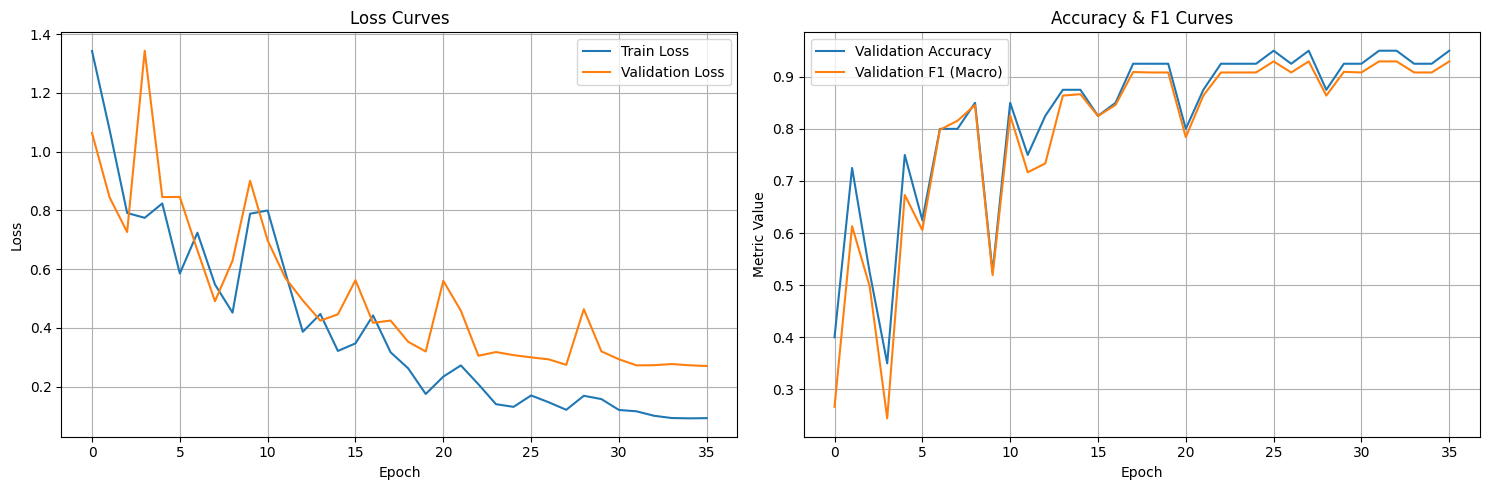

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Evaluating on Test Set...
Total samples loaded: 477
Train samples: 417
Validation samples: 40
Test samples: 20
Number of classes: 4


c:\Users\FERRA\miniconda3\envs\slr_py39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

Test Set Metrics: {
  "test_loss": 0.19319681823253632,
  "test_acc": 0.8999999761581421,
  "test_f1": 0.899495005607605
}


Generating Test Predictions:   0%|          | 0/1 [00:00<?, ?it/s]


Classification Report (Test Set):
              precision    recall  f1-score   support

     clavier       0.80      0.80      0.80         5
  disque_dur       1.00      0.80      0.89         5
  ordinateur       0.83      1.00      0.91         5
      souris       1.00      1.00      1.00         5

    accuracy                           0.90        20
   macro avg       0.91      0.90      0.90        20
weighted avg       0.91      0.90      0.90        20


Confusion Matrix (Test Set):


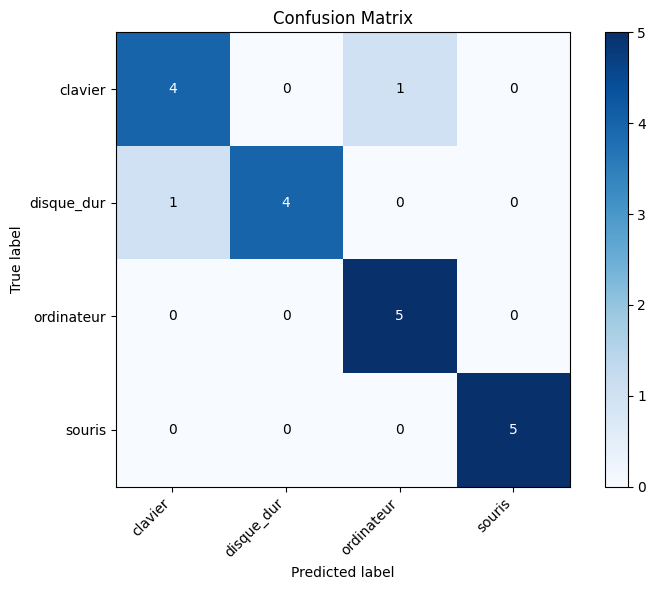

In [32]:
import pandas as pd
def plot_training_curves(log_dir):
    metrics_path = Path(log_dir) / "metrics.csv"
    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return

    metrics_df = pd.read_csv(metrics_path)
    
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    if 'train_loss_epoch' in metrics_df.columns:
        plt.plot(metrics_df['epoch'].dropna().unique(), metrics_df.groupby('epoch')['train_loss_epoch'].mean(), label='Train Loss')
    if 'val_loss' in metrics_df.columns:
        plt.plot(metrics_df['epoch'].dropna().unique(), metrics_df.groupby('epoch')['val_loss'].mean(), label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    if 'train_acc_epoch' in metrics_df.columns:
         plt.plot(metrics_df['epoch'].dropna().unique(), metrics_df.groupby('epoch')['train_acc_epoch'].mean(), label='Train Accuracy')
    if 'val_acc' in metrics_df.columns:
        plt.plot(metrics_df['epoch'].dropna().unique(), metrics_df.groupby('epoch')['val_acc'].mean(), label='Validation Accuracy')
    if 'val_f1' in metrics_df.columns:
        plt.plot(metrics_df['epoch'].dropna().unique(), metrics_df.groupby('epoch')['val_f1'].mean(), label='Validation F1 (Macro)')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.title('Accuracy & F1 Curves')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def display_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(8, len(class_names)), max(6, len(class_names))))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

if trainer and data_module:
    best_model_path = trainer.checkpoint_callback.best_model_path
    if best_model_path and Path(best_model_path).exists():
        print(f"\nLoading best model from: {best_model_path}")
        trained_model = LSTMClassifier.load_from_checkpoint(best_model_path)
        trained_model.eval()
        
        if hasattr(trainer.logger, 'log_dir'):
            plot_training_curves(trainer.logger.log_dir)
        else:
            print("Logger log_dir not found, cannot plot curves automatically.")

        print("\nEvaluating on Test Set...")
        test_results = trainer.test(model=trained_model, datamodule=data_module, verbose=False)
        if test_results:
             print("Test Set Metrics:", json.dumps(test_results[0], indent=2))

        test_loader = data_module.test_dataloader()
        if test_loader:
            all_preds = []
            all_targets = []
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            trained_model.to(device)

            with torch.no_grad():
                for batch in tqdm(test_loader, desc="Generating Test Predictions"):
                    x, y_true = batch
                    x = x.to(device)
                    logits = trained_model(x)
                    preds = torch.argmax(logits, dim=1).cpu().numpy()
                    all_preds.extend(preds)
                    all_targets.extend(y_true.cpu().numpy())
            
            if all_targets and all_preds:
                class_names_eval = [data_module.inv_label_map[i] for i in range(data_module.num_classes)]
                print("\nClassification Report (Test Set):")
                print(classification_report(all_targets, all_preds, target_names=class_names_eval, zero_division=0))
                
                print("\nConfusion Matrix (Test Set):")
                display_confusion_matrix(all_targets, all_preds, class_names_eval)
    else:
        print("Best model path not found. Skipping detailed evaluation.")
        trained_model = None
else:
    print("Trainer or DataModule not available. Skipping evaluation.")
    trained_model = None

### Inference on a New Video


--- Inference on a Sample Video ---
Running inference on: SignLanguageDataset\disque_dur\disque_dur38.mp4

Predicted Class: disque_dur (Confidence: 0.99)



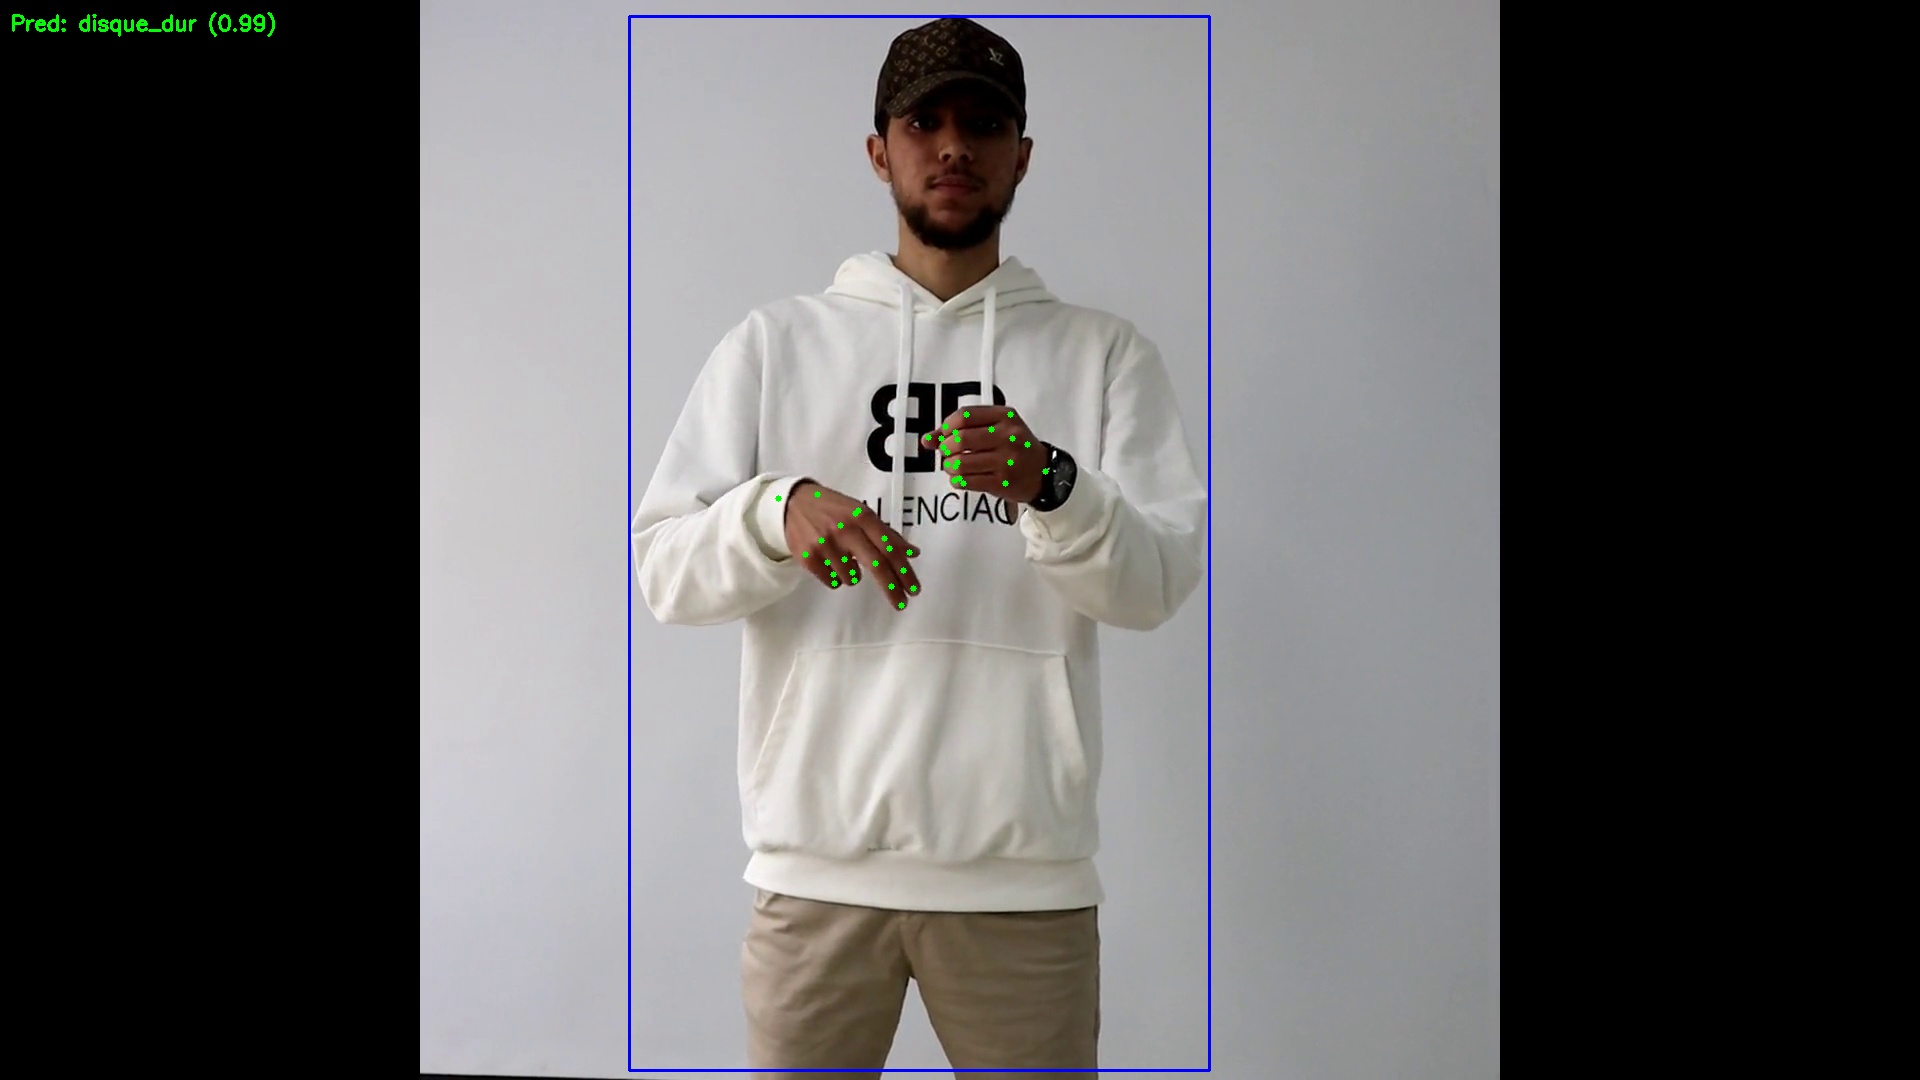
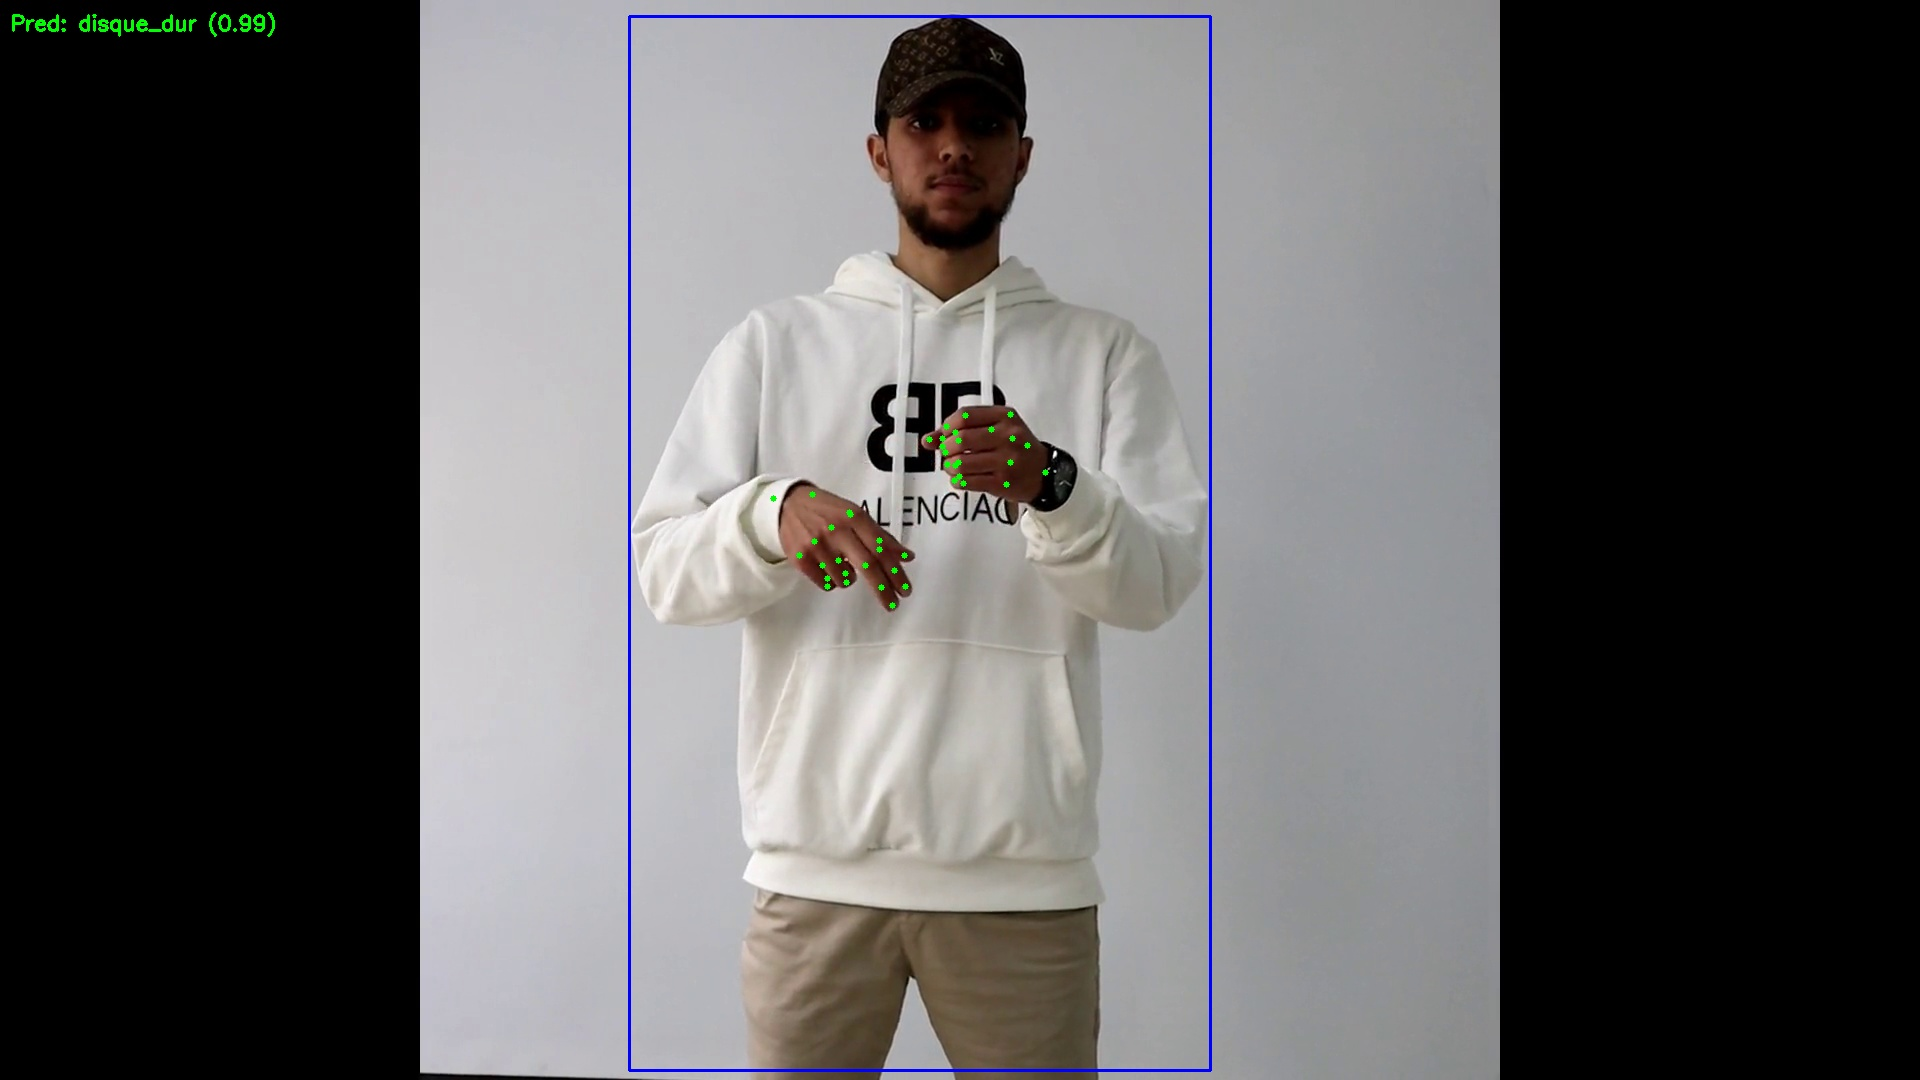
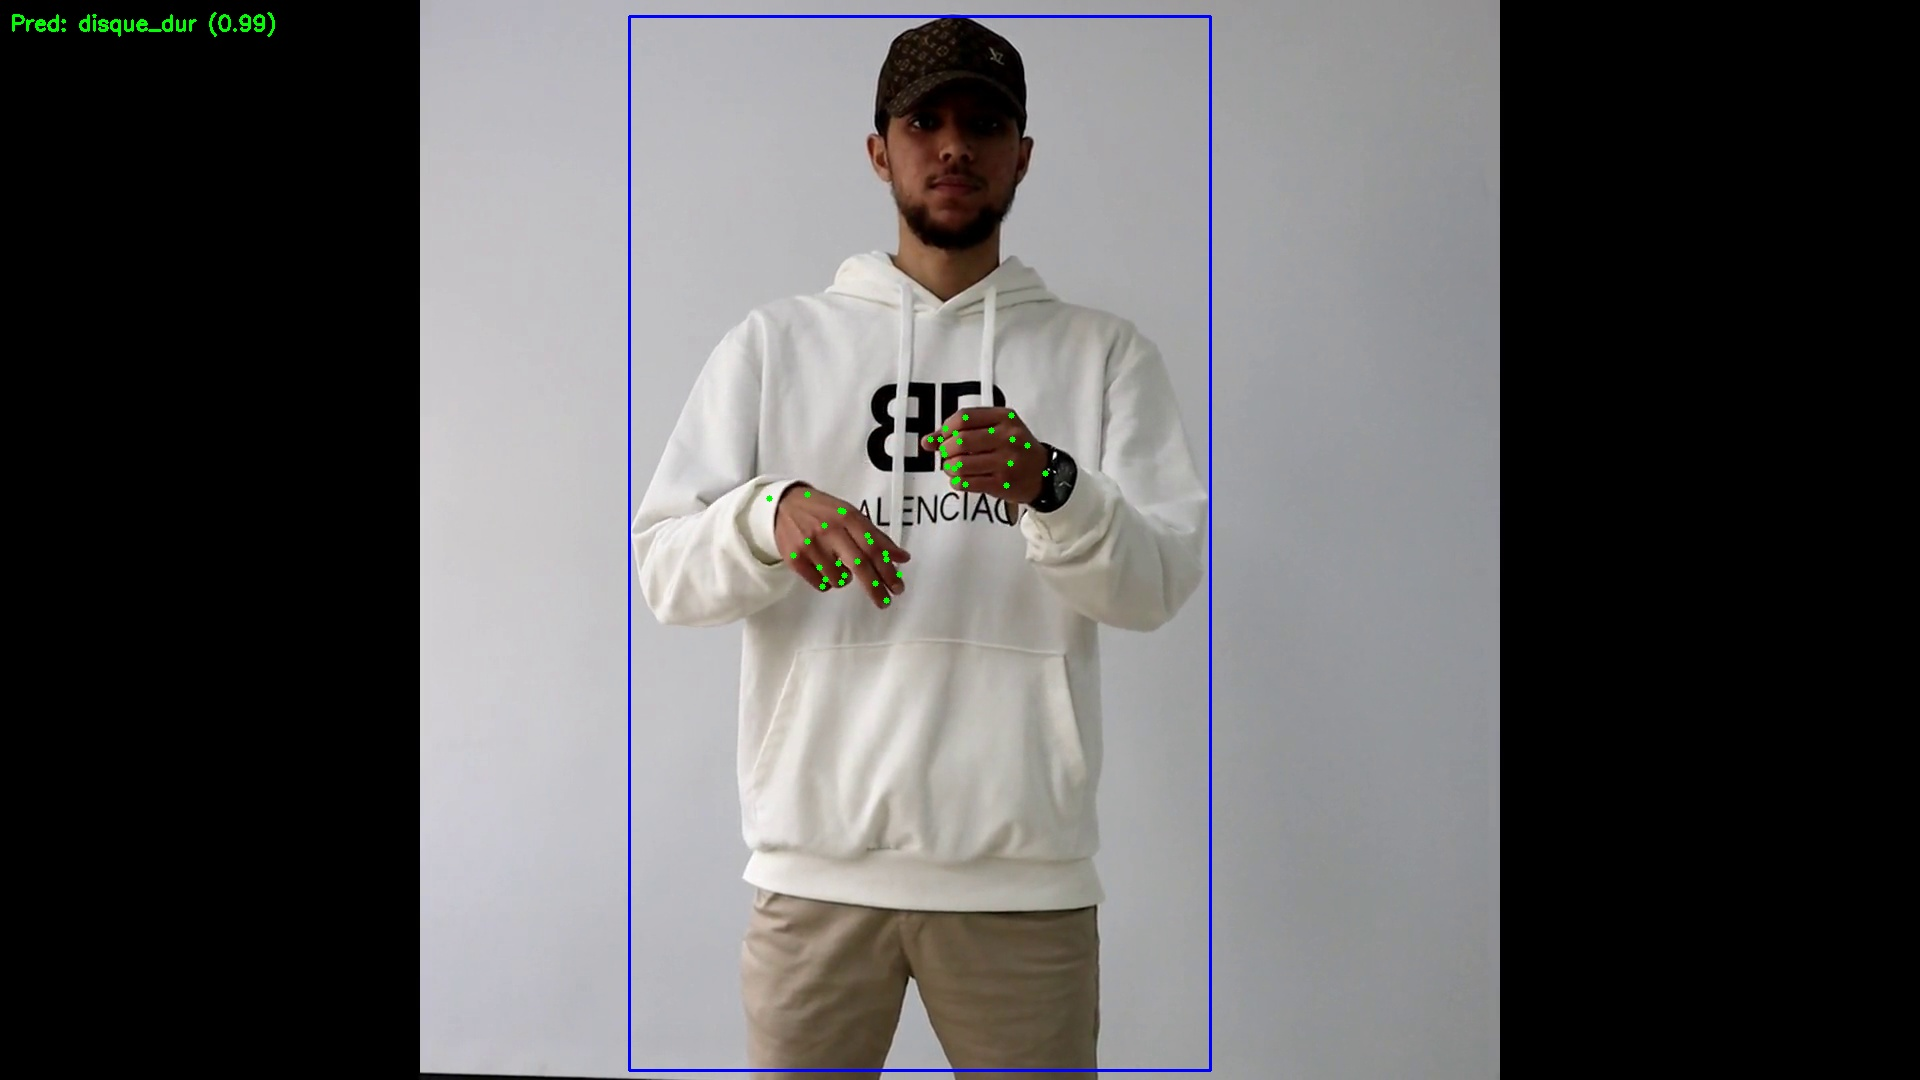
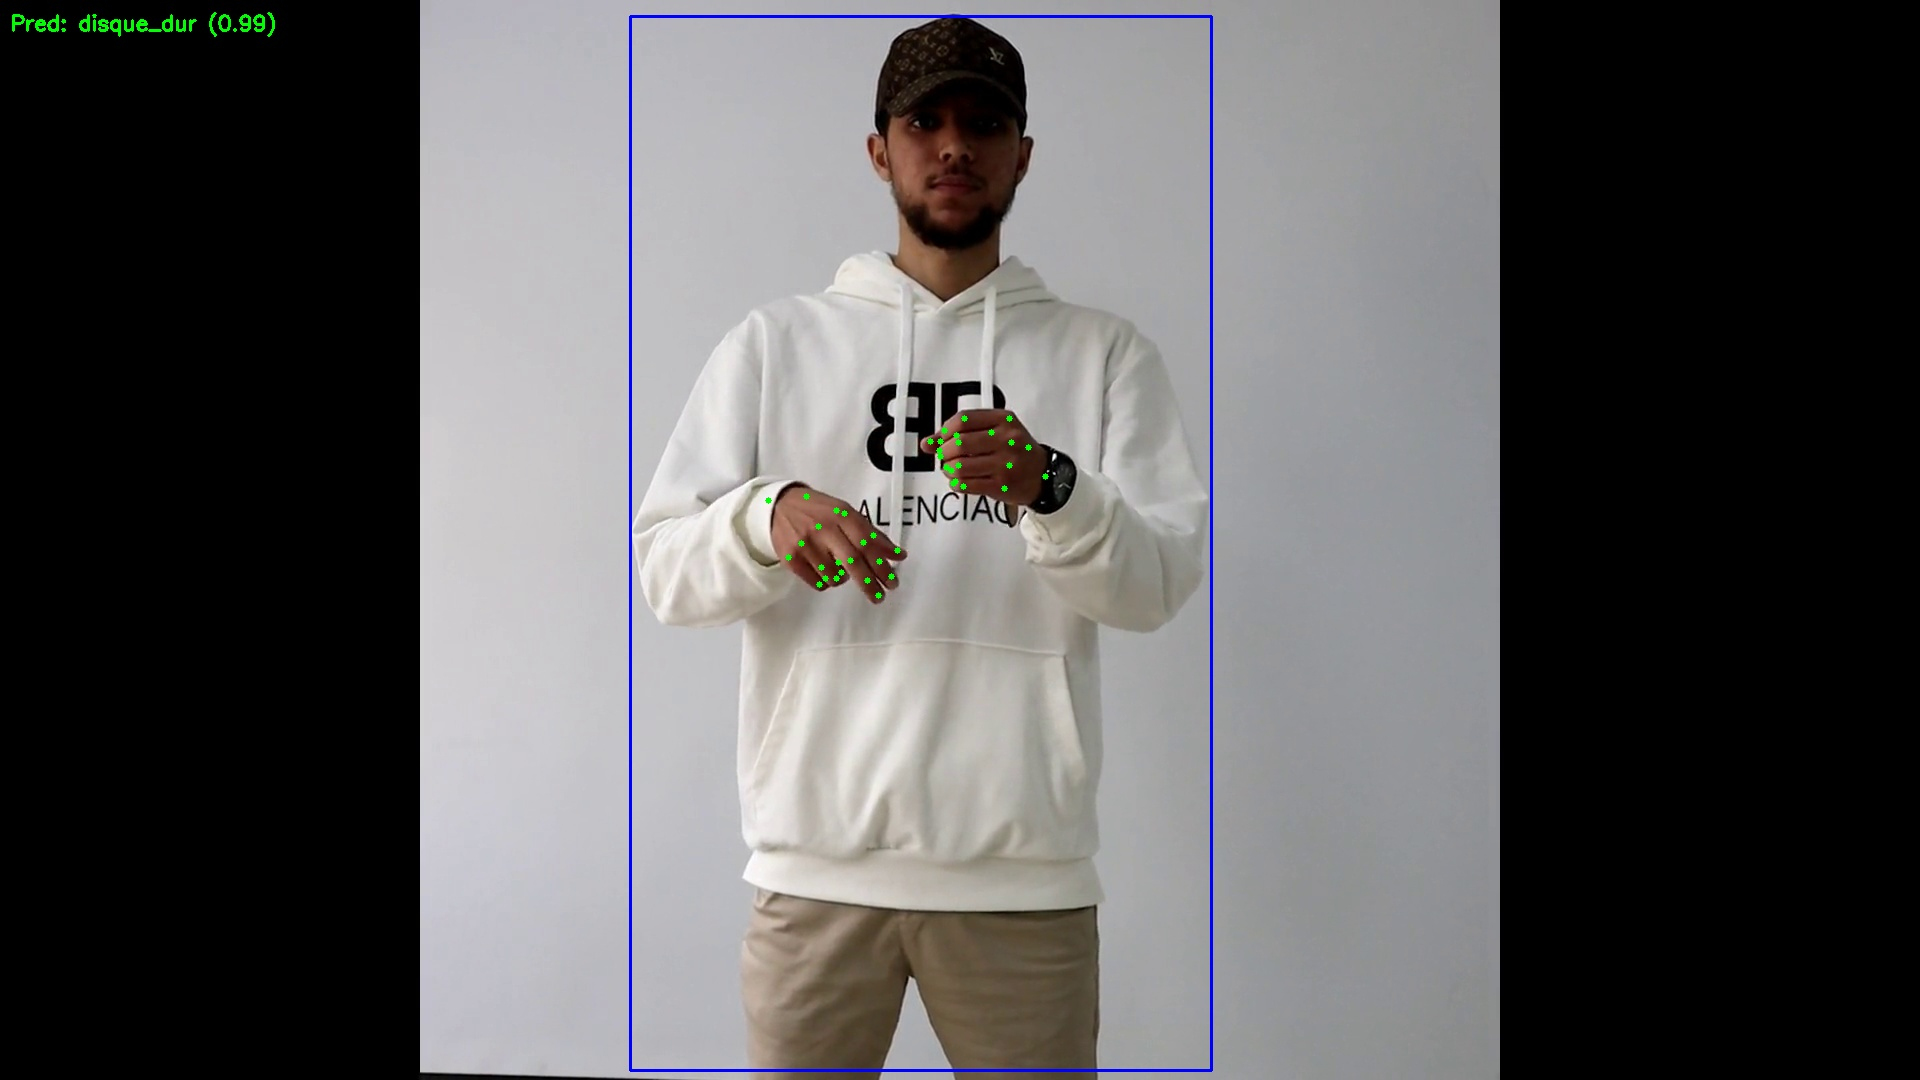
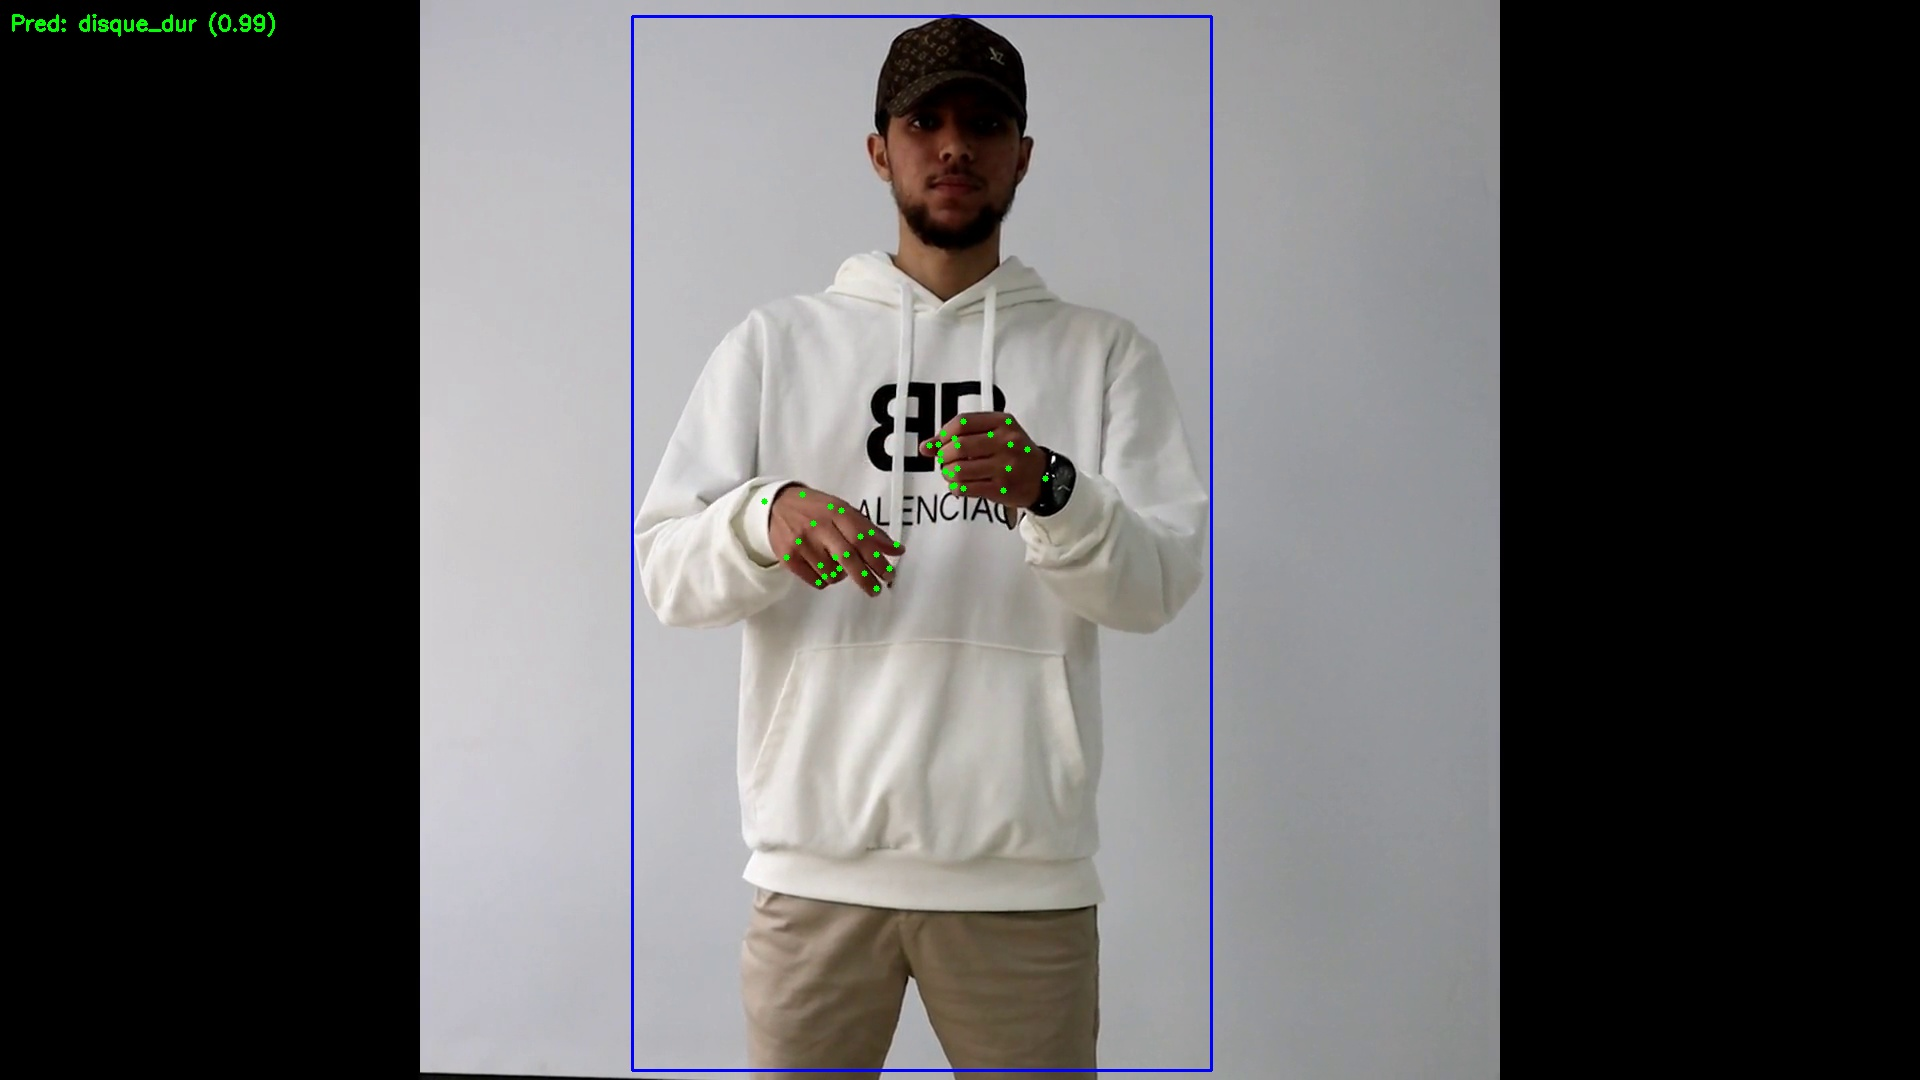
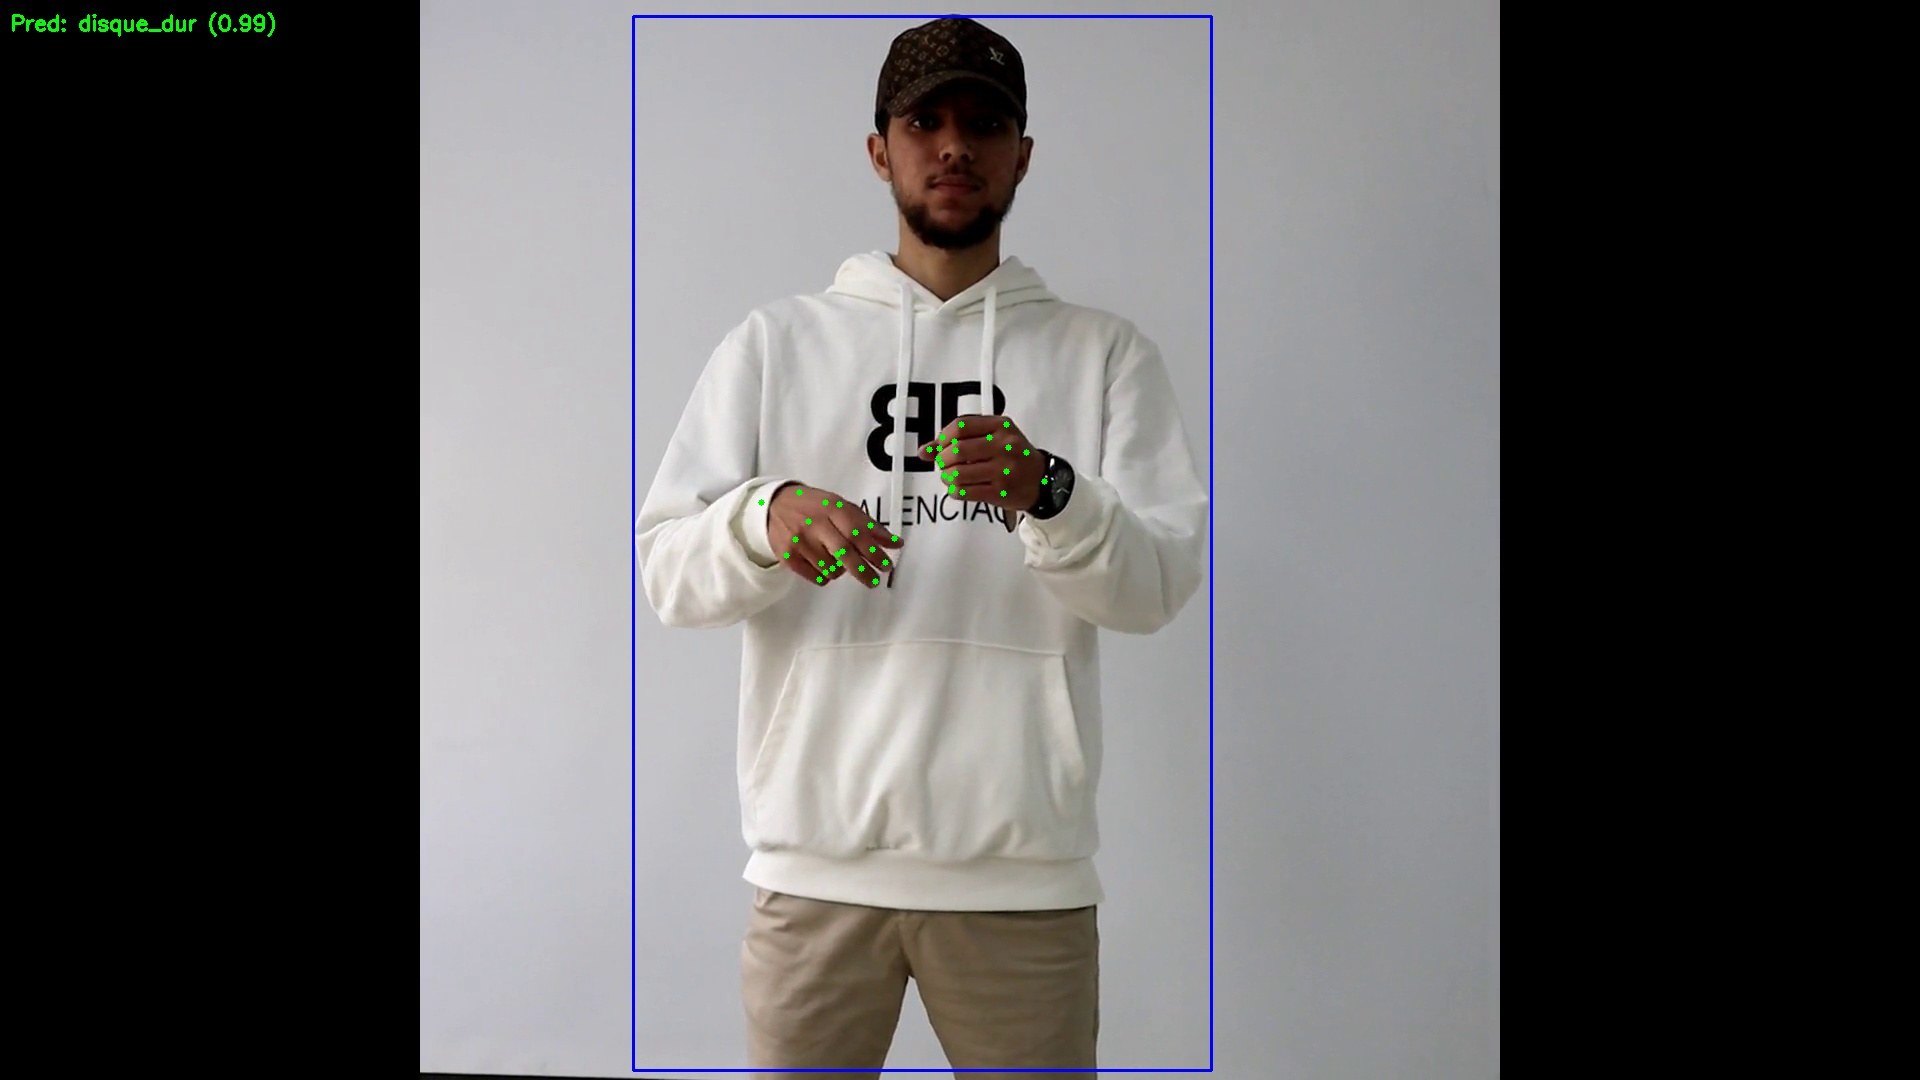
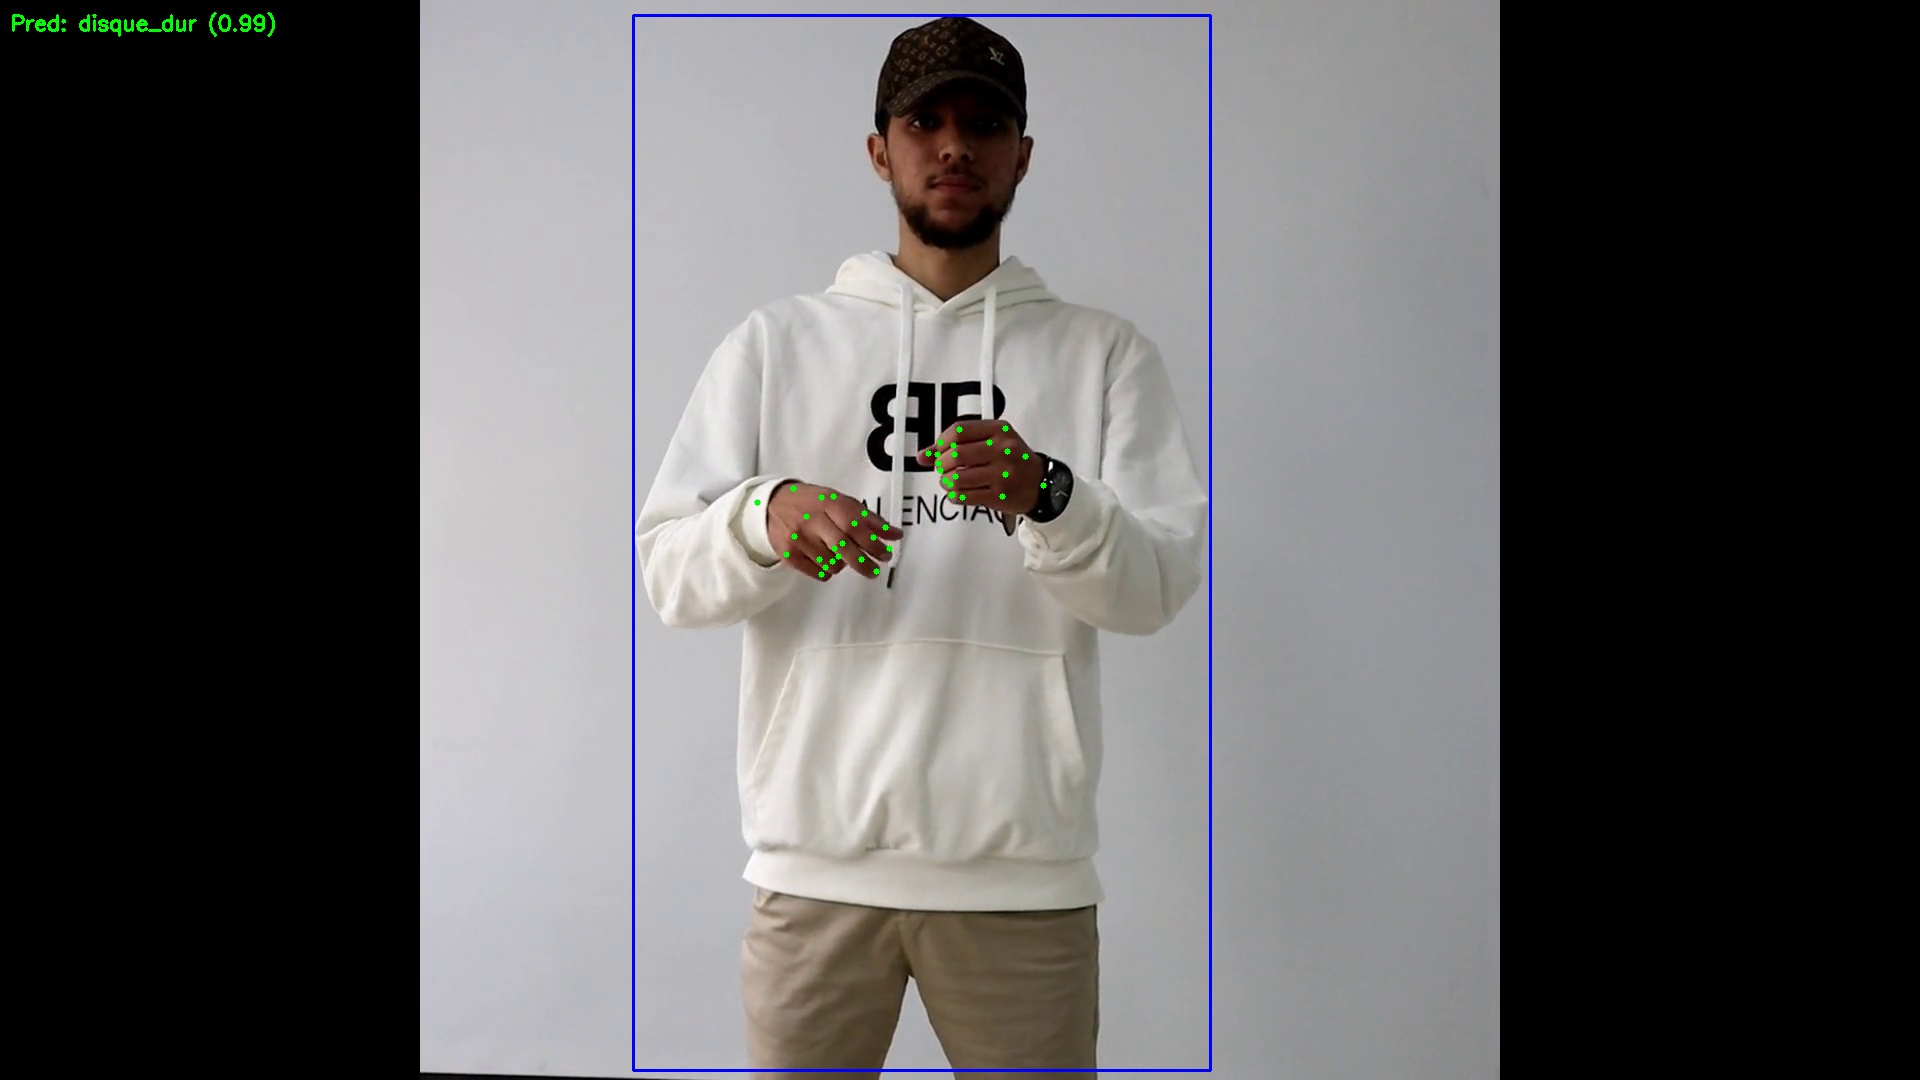
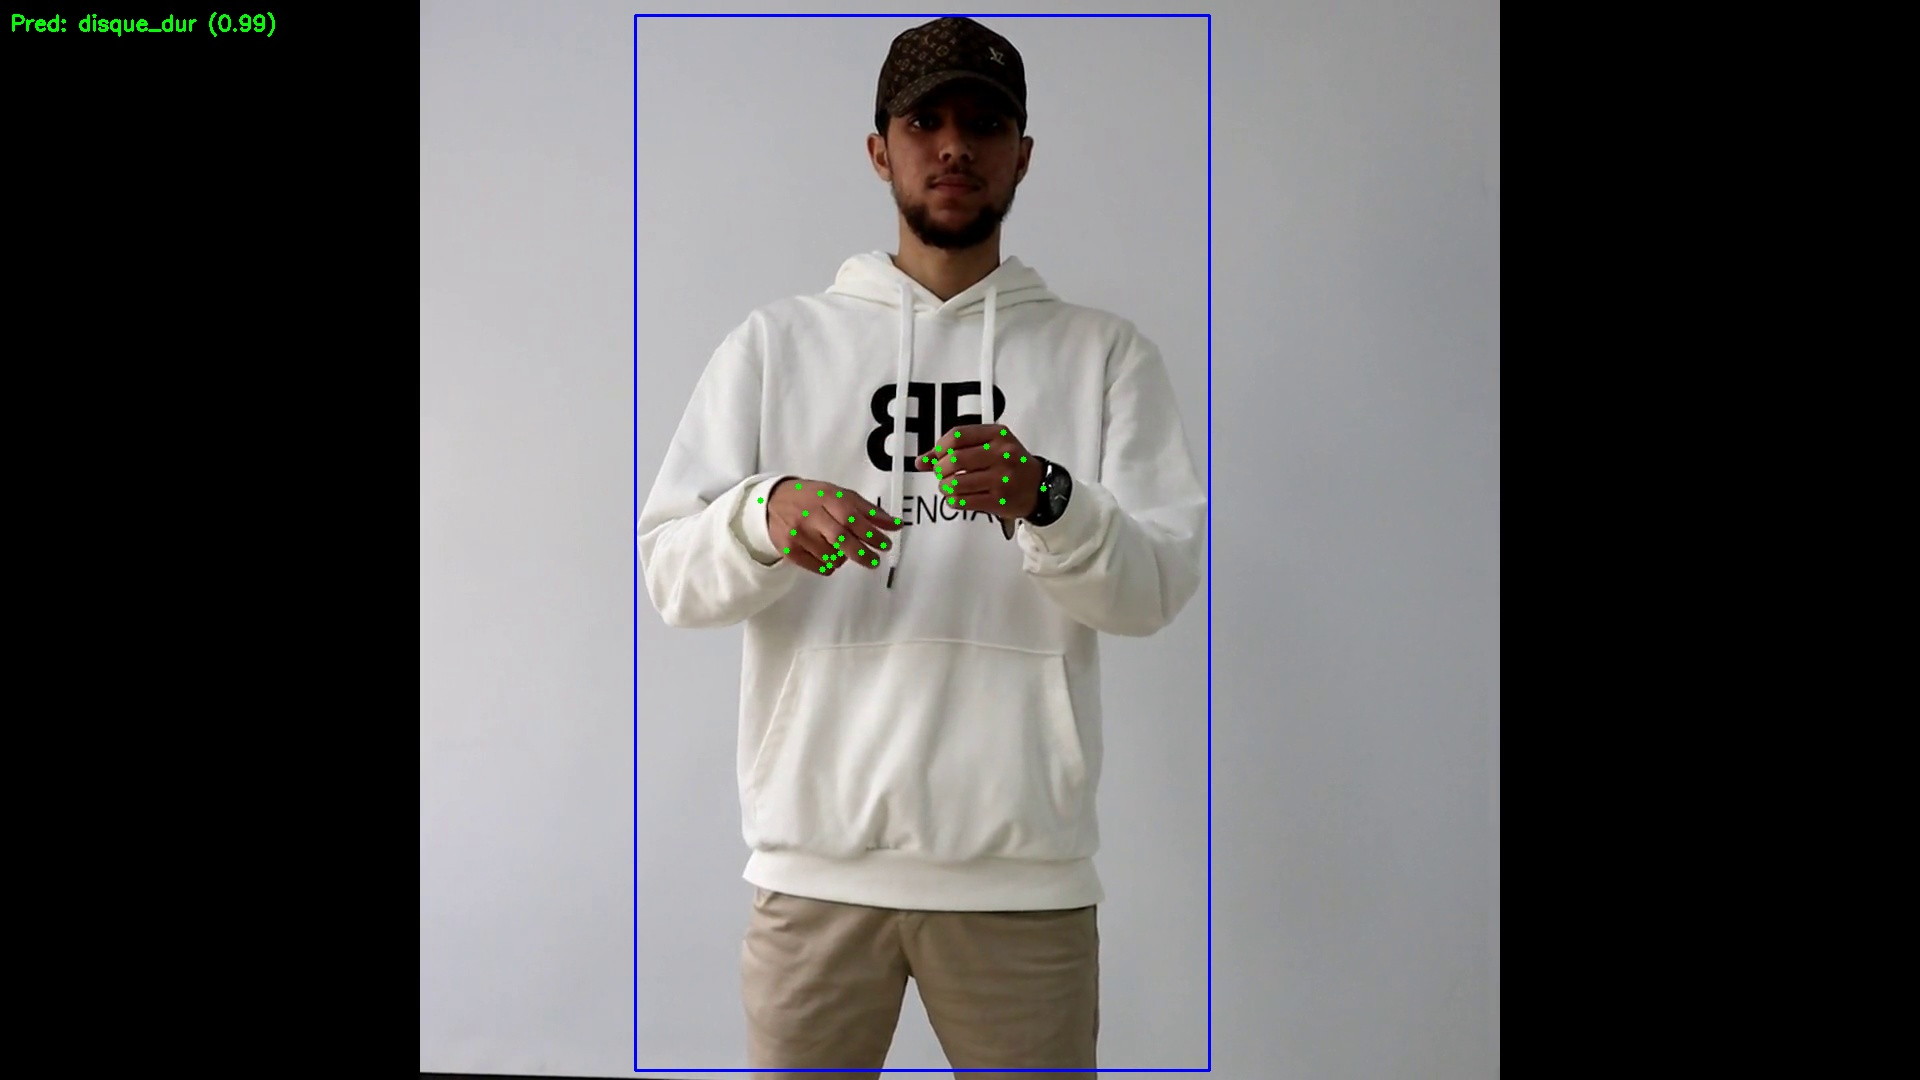
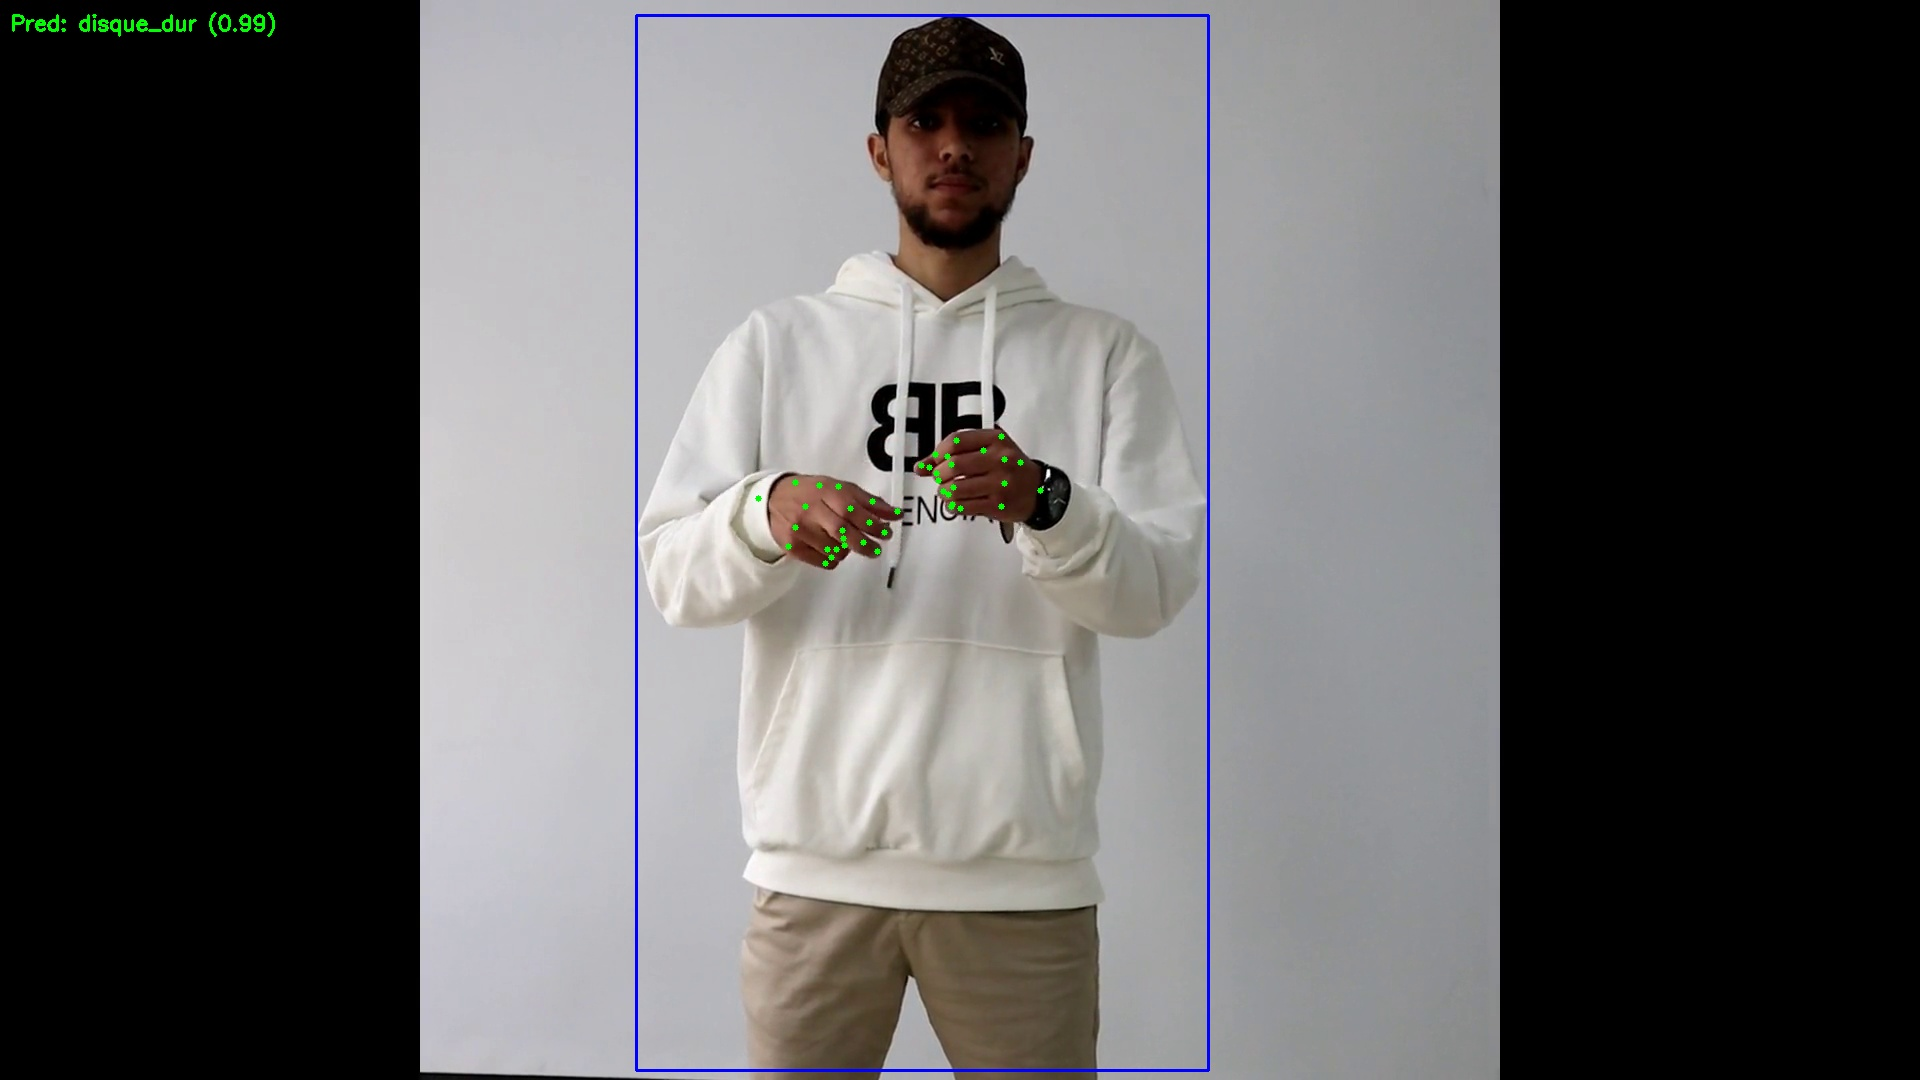
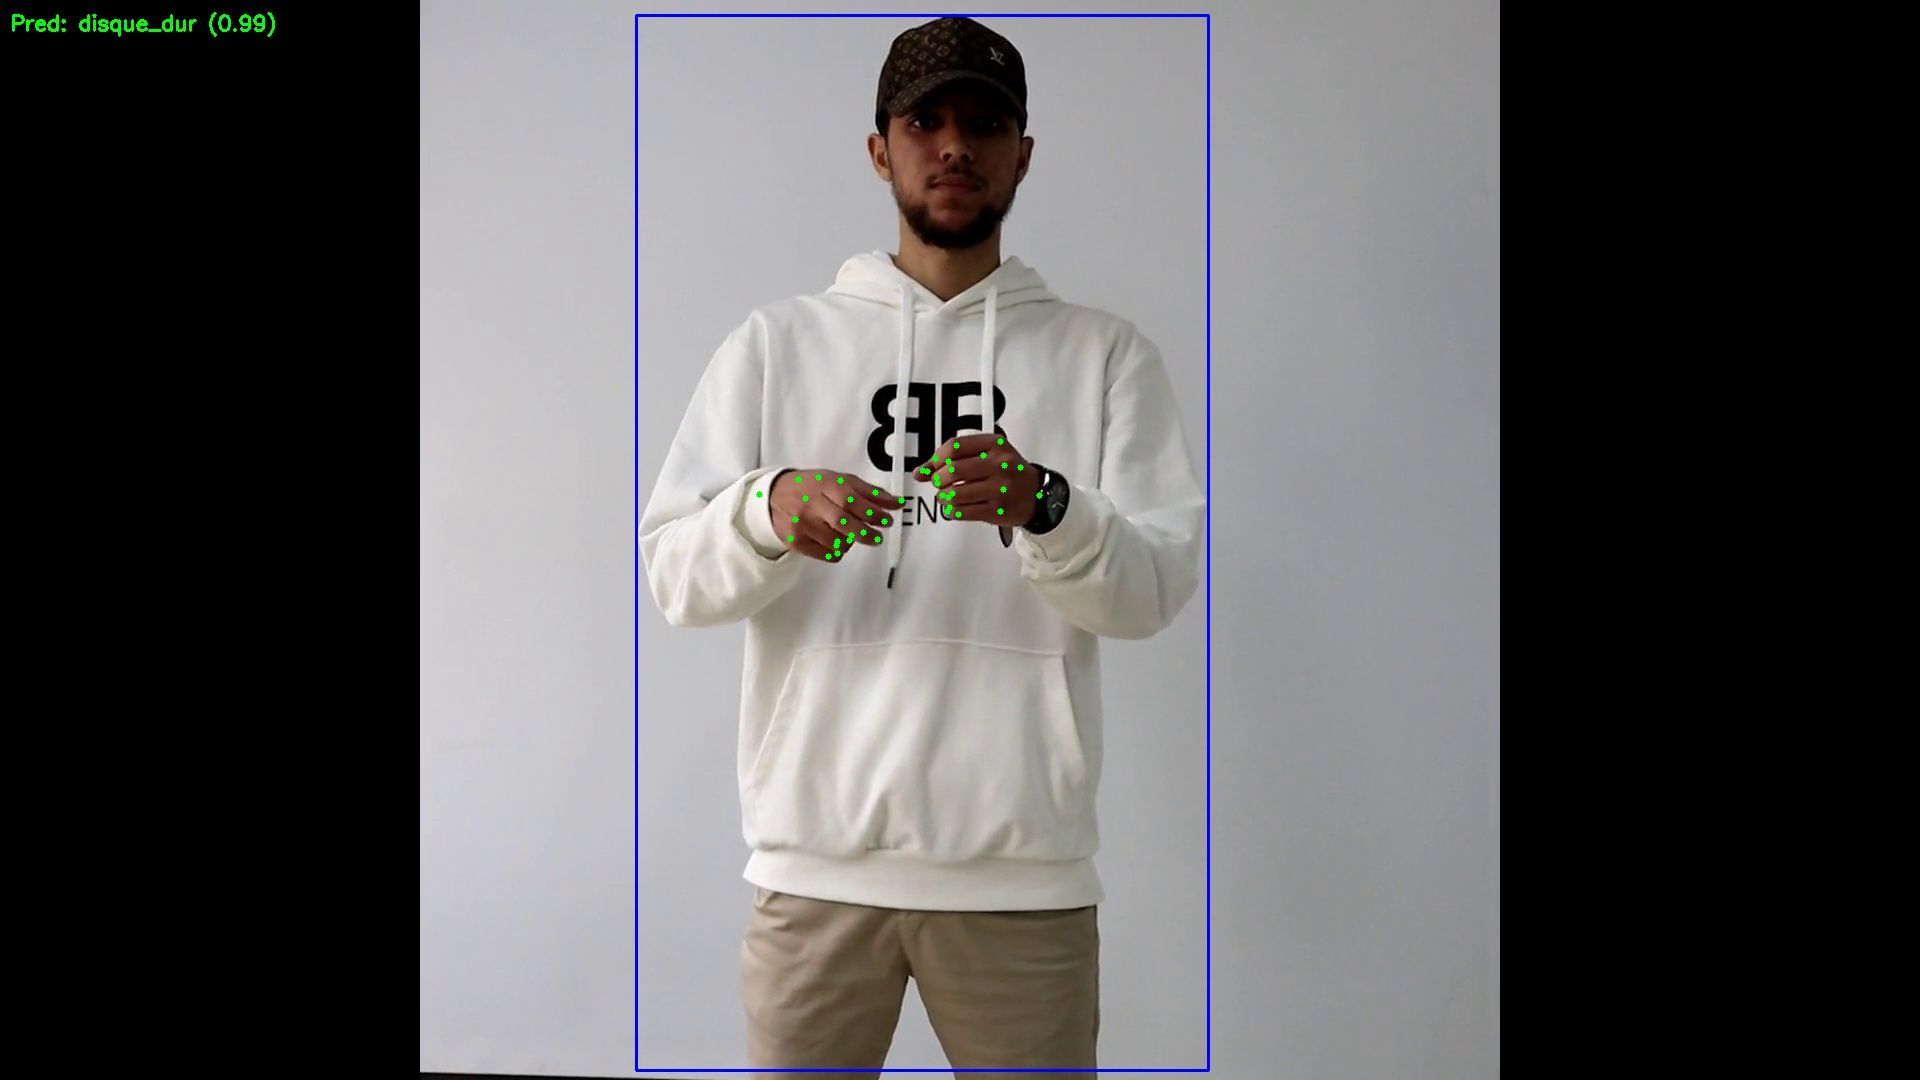
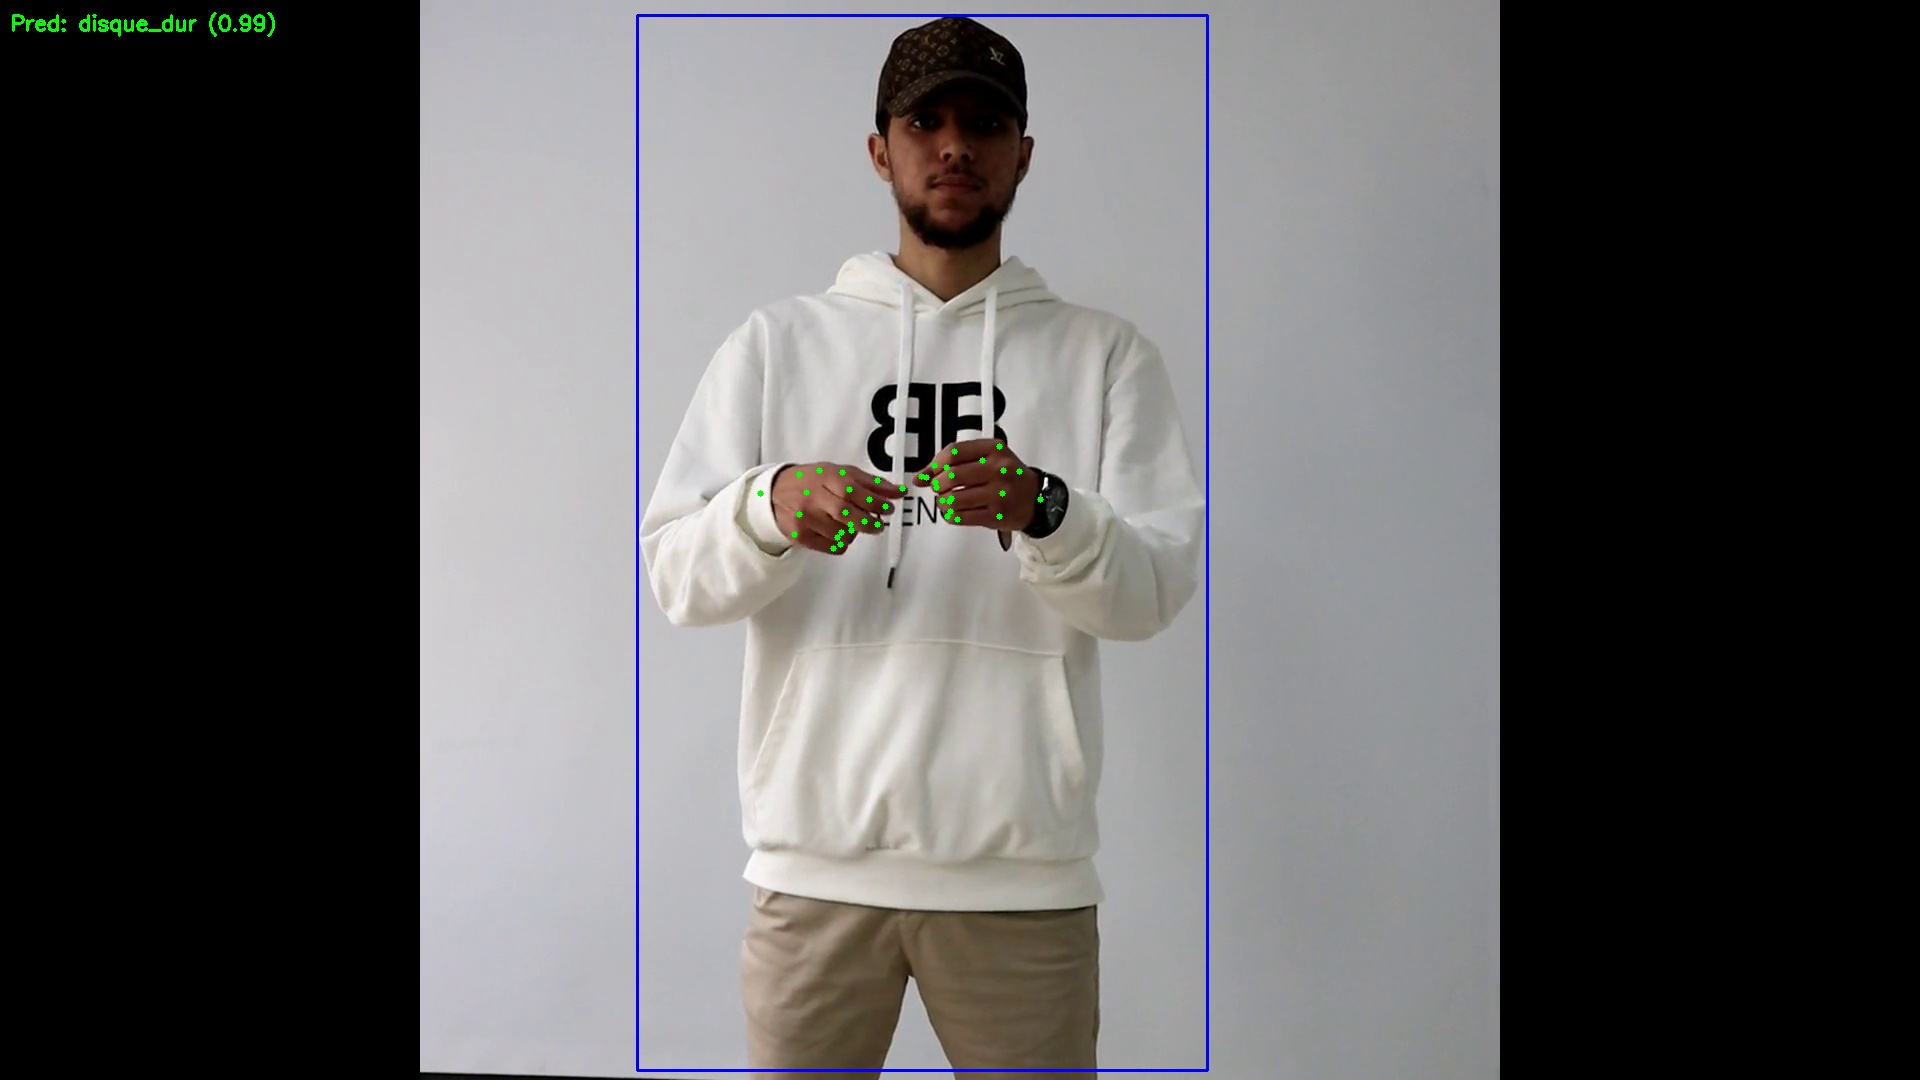
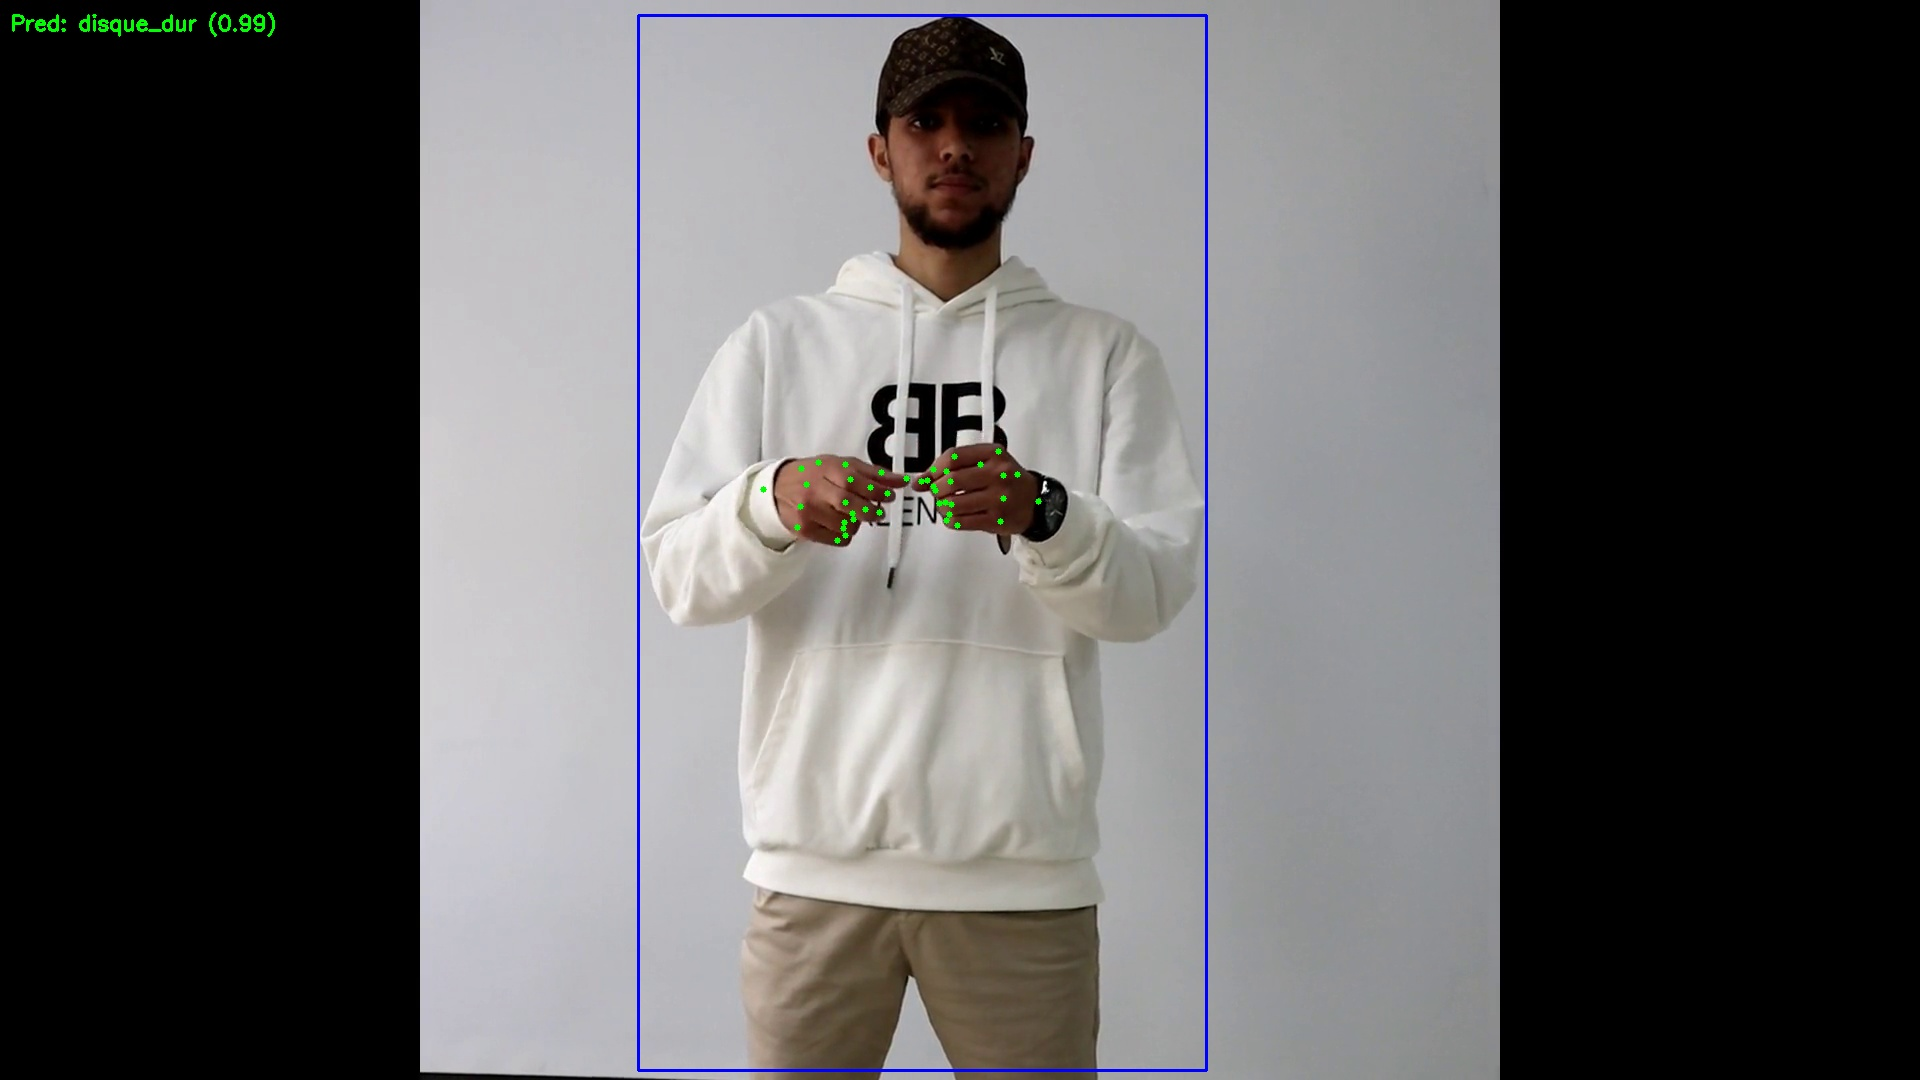
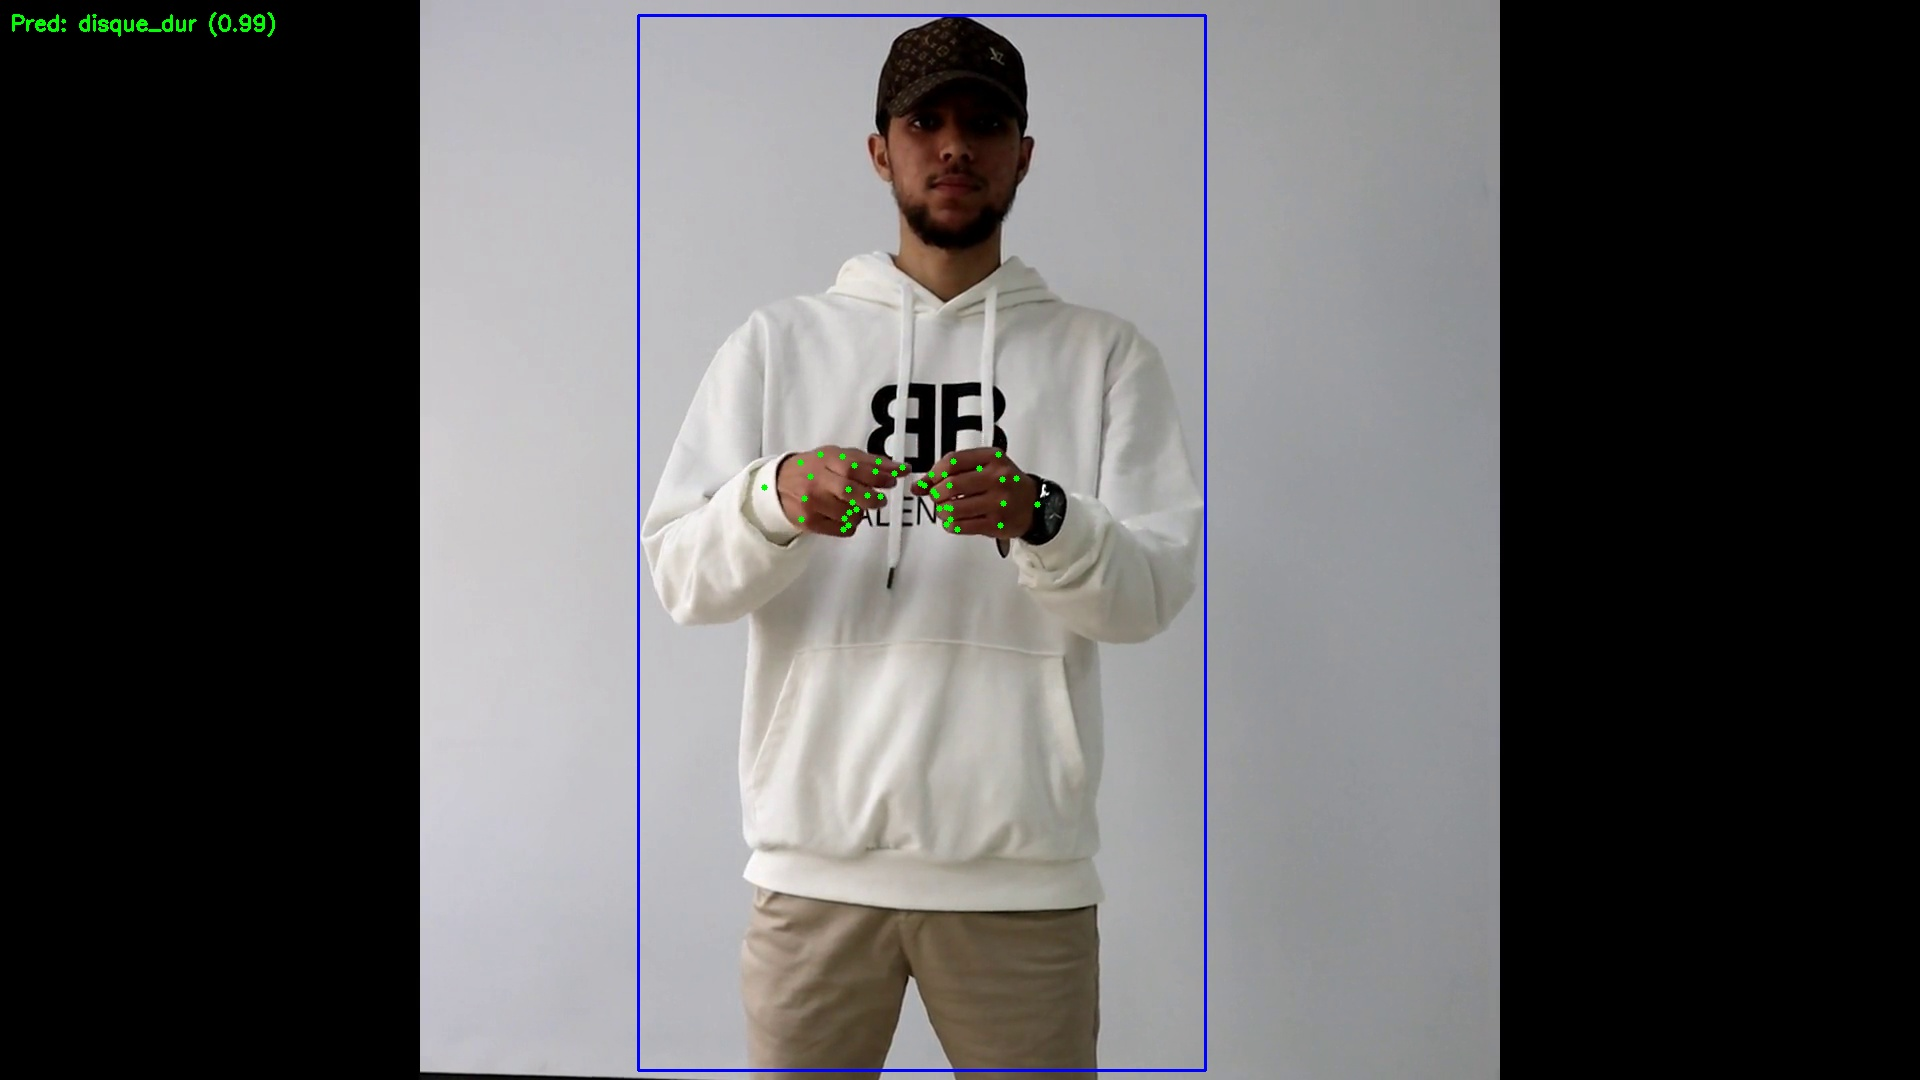
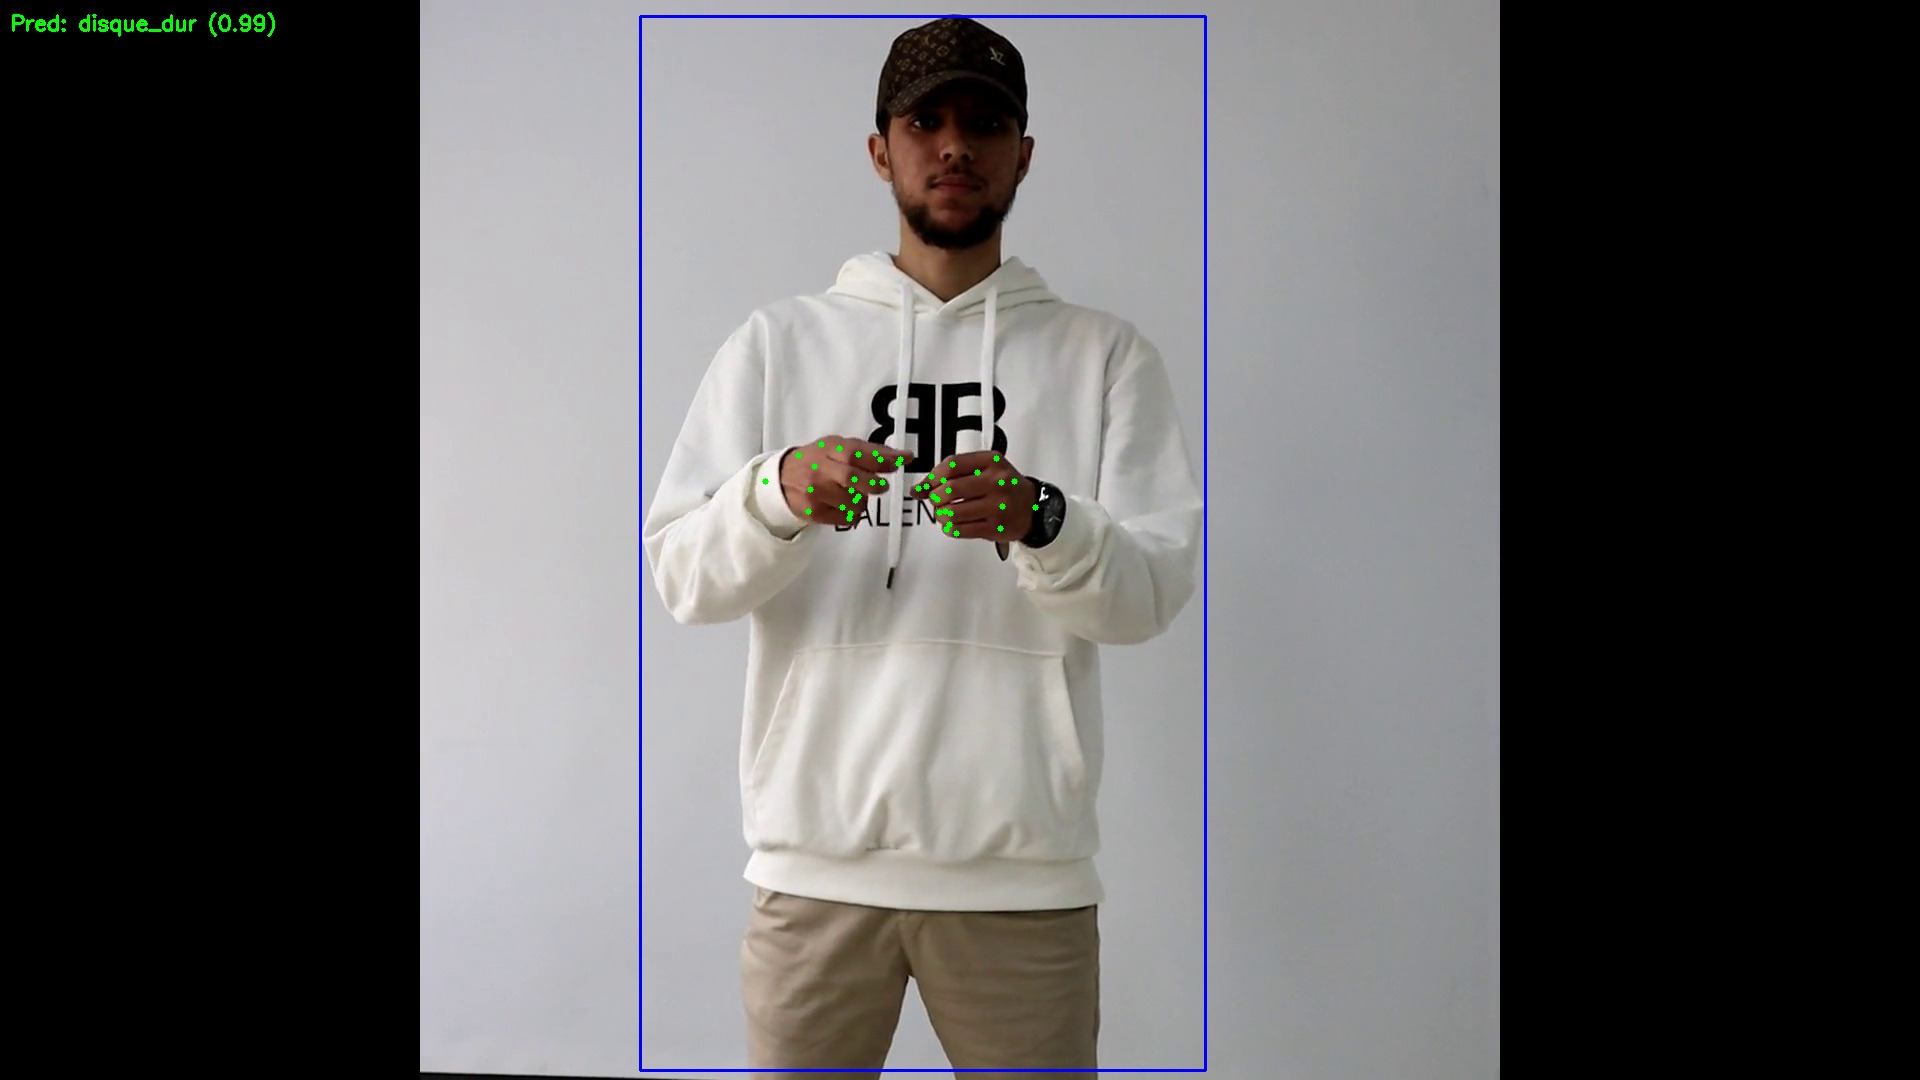
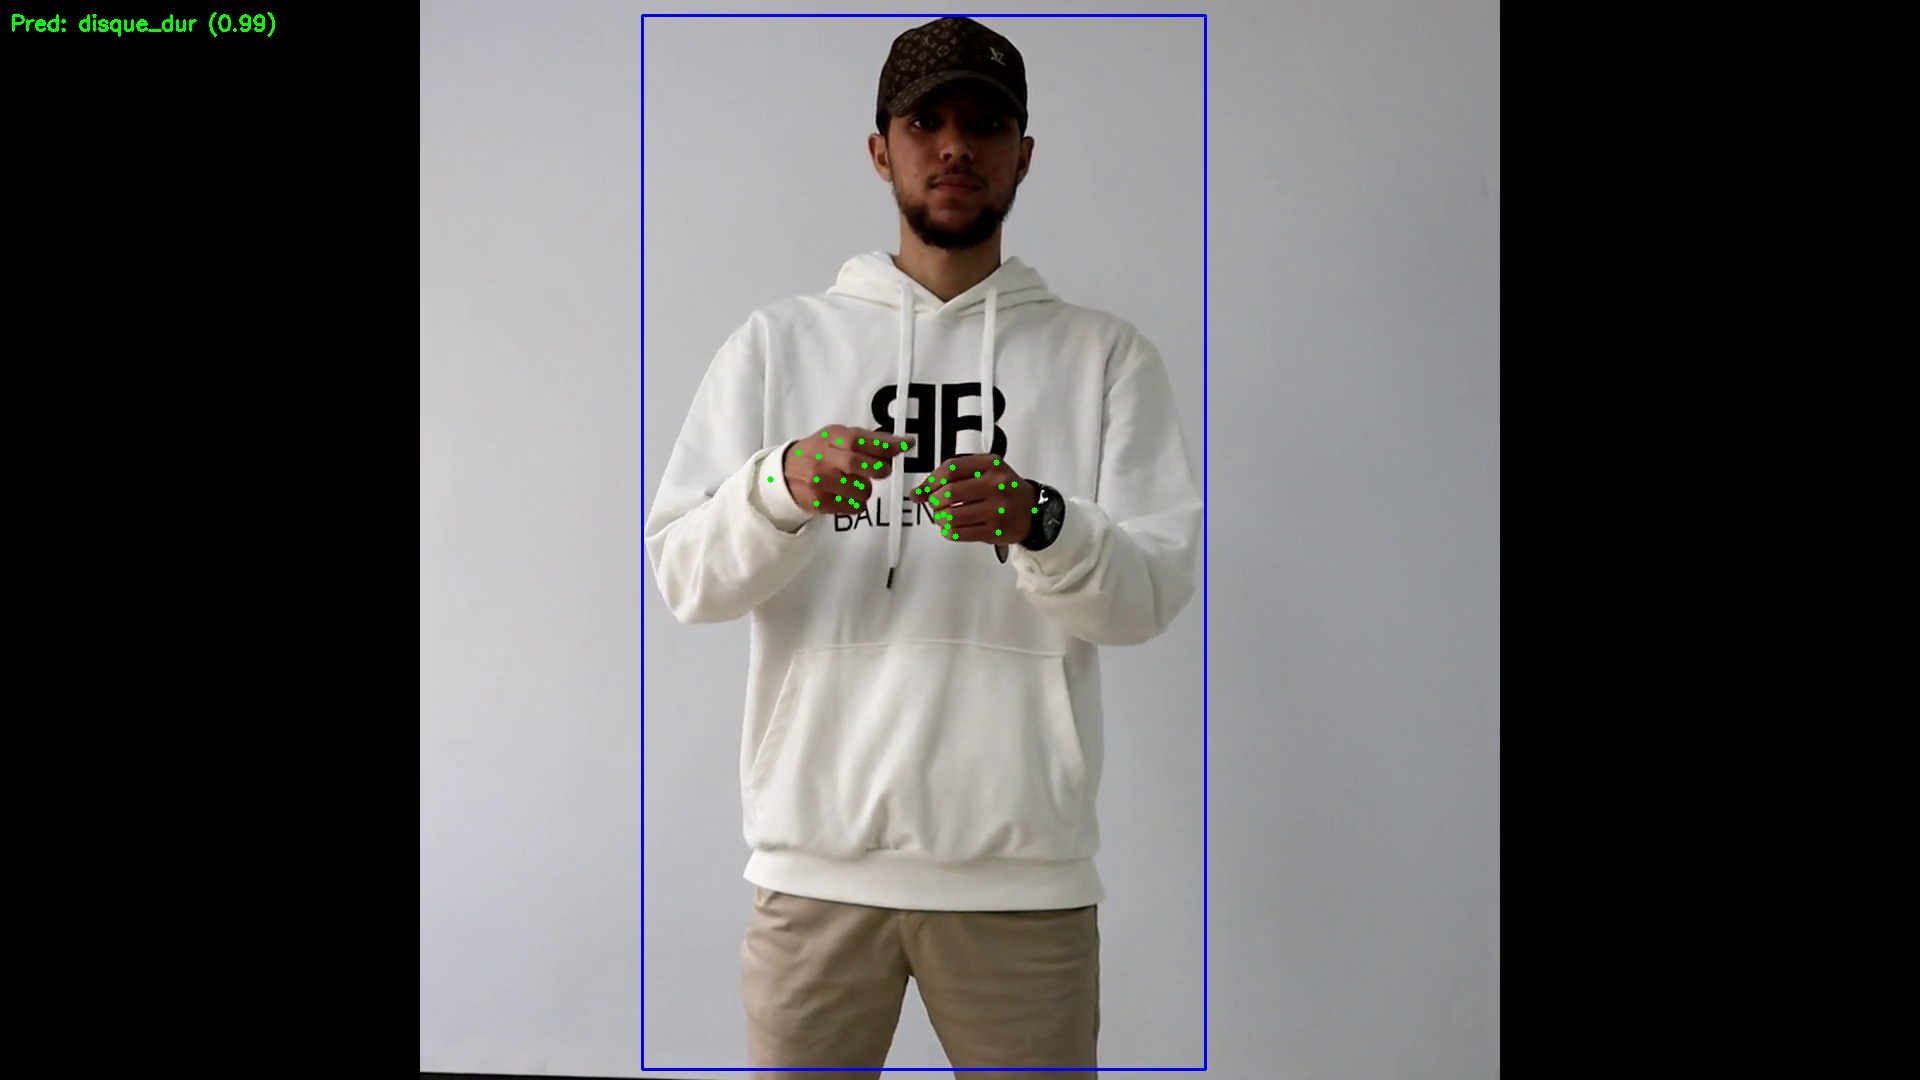

In [37]:
if trained_model and data_module and yolo_detector is not None:
    print("\n--- Inference on a Sample Video ---")

    # We pick a video from the original raw directory for a true inference test
    all_videos_for_inference = list(RAW_VIDEO_DATA_DIR.glob("**/*.mp4"))
    if not all_videos_for_inference:
        print("No videos found for inference demo.")
    else:
        inference_video_path = random.choice(all_videos_for_inference)
        print(f"Running inference on: {inference_video_path}")

        cap = cv2.VideoCapture(str(inference_video_path))
        if not cap.isOpened():
            print(f"Error: Could not open video {inference_video_path}")
        else:
            video_keypoints_list_inf = []
            processed_frames_for_display = []

            with mp_hands.Hands(
                    static_image_mode=False, max_num_hands=MAX_NUM_HANDS_MEDIAPIPE,
                    min_detection_confidence=MIN_DETECTION_CONF_MEDIAPIPE,
                    min_tracking_confidence=MIN_TRACKING_CONF_MEDIAPIPE) as hands_solution_inf:
                
                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret: break
                    keypoints_single_frame_inf, frame_annotated_inf = process_frame_for_keypoints(frame, hands_solution_inf, yolo_detector)
                    video_keypoints_list_inf.append(keypoints_single_frame_inf)
                    processed_frames_for_display.append(frame_annotated_inf)

            cap.release()

            if video_keypoints_list_inf:
                video_keypoints_np_inf = np.array(video_keypoints_list_inf, dtype=np.float32)
                if video_keypoints_np_inf.shape[0] > NUM_FRAMES_PER_VIDEO:
                    start_inf = (video_keypoints_np_inf.shape[0] - NUM_FRAMES_PER_VIDEO) // 2
                    processed_sequence_inf = video_keypoints_np_inf[start_inf : start_inf + NUM_FRAMES_PER_VIDEO]
                    processed_frames_for_display = processed_frames_for_display[start_inf : start_inf + NUM_FRAMES_PER_VIDEO]
                else:
                    padding_inf = np.zeros((NUM_FRAMES_PER_VIDEO - video_keypoints_np_inf.shape[0], INPUT_SIZE), dtype=np.float32)
                    processed_sequence_inf = np.concatenate((video_keypoints_np_inf, padding_inf), axis=0)

                sequence_tensor_inf = torch.from_numpy(processed_sequence_inf).float().unsqueeze(0)
                device_inf = torch.device("cuda" if torch.cuda.is_available() else "cpu")
                trained_model.to(device_inf)
                trained_model.eval()
                sequence_tensor_inf = sequence_tensor_inf.to(device_inf)

                with torch.no_grad():
                    logits_inf = trained_model(sequence_tensor_inf)
                    probabilities_inf = torch.softmax(logits_inf, dim=1)
                    confidence_inf, predicted_idx_inf = torch.max(probabilities_inf, dim=1)
                    predicted_class_name_inf = data_module.inv_label_map.get(predicted_idx_inf.item(), "Unknown")
                    prediction_confidence = confidence_inf.item()

                print(f"\nPredicted Class: {predicted_class_name_inf} (Confidence: {prediction_confidence:.2f})")

                if processed_frames_for_display:
                    output_html_frames = []
                    for display_frame in processed_frames_for_display:
                        cv2.putText(display_frame, f"Pred: {predicted_class_name_inf} ({prediction_confidence:.2f})",
                                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                        _, buffer = cv2.imencode('.jpg', display_frame)
                        import base64
                        img_base64 = base64.b64encode(buffer.tobytes()).decode('utf-8')
                        output_html_frames.append(f'<img src="data:image/jpeg;base64,{img_base64}" style="width:320px; margin:2px;" />')
                    
                    html_content = f"<p>Video: <strong>{inference_video_path.name}</strong> -> Predicted: <strong>{predicted_class_name_inf}</strong></p><div>{''.join(output_html_frames[:15])}</div>"
                    display(HTML(html_content))
else:
    print("Trained model, DataModule, or YOLO detector not available. Skipping inference.")

In [34]:
print("\nNotebook execution finished.")


Notebook execution finished.
